# Audio Model Creation and Quantization

This notebook demonstrates the process of training, quantizing, and evaluating audio models. The workflow includes:

1. Auto Model Generation
2. Model Training and Pruning
3. Quantization (Post-Training and Quantization-Aware)
4. Evaluation of Quantized Models
5. Analysis of Model Size vs. Accuracy

## SCC stuff

In [1]:
#when using scc and selecting jupyter modules use these in this order
#python3/3.10.12 tensorflow/2.11.0

# Imports and GPU


In [83]:
# Import basic functionality libraries
import os
import pathlib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
import tempfile
import shutil
import sys
import gc
import zipfile
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# More specific tf import such as autotuner
from tensorflow.keras import layers
from IPython import display
import keras_tuner as kt
from tensorflow.keras.layers import Conv2D, DepthwiseConv2D, GlobalAveragePooling2D, Dense, Activation, Input, Reshape, Multiply, AveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, ReLU, Dropout
from tensorflow.keras import Sequential

# Libraries for model optimizations
import tensorflow_model_optimization as tfmot
#from tensorflow_model_optimization.python.core.keras.compat import keras
from keras.layers import Resizing
from tensorflow_model_optimization.quantization.keras import quantize_annotate_layer
import nbimporter
#import tf_keras as keras #this one worked for local

In [3]:
# for SCC
import tensorflow.keras as keras

## Setup tensorflow GPU support

In [4]:
use_gpu = True # set it here by hand

if use_gpu:
    # Check if GPU is available
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            # Currently, memory growth needs to be the same across GPUs
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            logical_gpus = tf.config.list_logical_devices('GPU')
            print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        except RuntimeError as e:
            # Memory growth must be set before GPUs have been initialized
            print(e)
    else:
        print("No GPU available")

1 Physical GPUs, 1 Logical GPUs


# Run .py preprocessing that sets up the datasets

The code below imports the datasets from serealized TFREcords, batches them, and results in the final train/test/val_spectrogram_ds datasets.

In [5]:
# Specify the path to your output dir|ectory where the .npy files are saved
output_dir = 'processed_dataset_small'  # Replace with your actual output directory

# Load the features and labels
features = np.load(os.path.join(output_dir, 'features.npy'))
labels = np.load(os.path.join(output_dir, 'labels.npy'))

print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271086, 49, 40)
Labels shape: (271086,)


In [6]:
# Expand dimensions to add a channel dimension
features = np.expand_dims(features, -1)  # Shape becomes (num_samples, num_frames, num_mel_bins, 1)

# Split data into training + validation and test sets (80% training + validation, 20% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42, stratify=labels)

# Further split the training + validation set into training and validation sets (60% training, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Training set shape: {X_train.shape}, Labels shape: {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, Labels shape: {y_val.shape}")
print(f"Test set shape: {X_test.shape}, Labels shape: {y_test.shape}")

Training set shape: (162651, 49, 40, 1), Labels shape: (162651,)
Validation set shape: (54217, 49, 40, 1), Labels shape: (54217,)
Test set shape: (54218, 49, 40, 1), Labels shape: (54218,)


In [7]:
np.unique(y_train)

array([0, 1, 2, 3])

In [8]:
# Compute mean and standard deviation from the training data
mean = np.mean(X_train)
std = np.std(X_train)

print(f"Training data mean: {mean:.4f}, standard deviation: {std:.4f}")

# Normalize the training data
X_train_norm = (X_train - mean) / std

# Normalize the validation data
X_val_norm = (X_val - mean) / std

# Normalize the test data
X_test_norm = (X_test - mean) / std



Training data mean: -4.7196, standard deviation: 5.2118


In [9]:
def serialize_example(image, label):
    """Creates a tf.train.Example message ready to be written to a file."""
    image = tf.cast(image * 255, tf.uint8)  # Scale to [0, 255] and cast to uint8
    jpeg_image = tf.image.encode_jpeg(image)  # Encode image as JPEG
    feature = {
        'image': tf.train.Feature(bytes_list=tf.train.BytesList(value=[jpeg_image.numpy()])),
        'label': tf.train.Feature(int64_list=tf.train.Int64List(value=[label])),
    }
    example_proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return example_proto.SerializeToString()

def write_tfrecord(filename, images, labels):
    with tf.io.TFRecordWriter(filename) as writer:
        for image, label in zip(images, labels):
            serialized_example = serialize_example(image, label)
            writer.write(serialized_example)
    print(f"TFRecord file created: {filename}")

# Step 3: Write each dataset to a separate TFRecord file
write_tfrecord('train_spec_ds.tfrecord', X_train_norm, y_train)
write_tfrecord('val_spec_ds.tfrecord', X_val_norm, y_val)
write_tfrecord('test_spec_ds.tfrecord', X_test_norm, y_test)

TFRecord file created: train_spec_ds.tfrecord
TFRecord file created: val_spec_ds.tfrecord
TFRecord file created: test_spec_ds.tfrecord


In [10]:
# Function to parse a single serialized example from TFRecord
def _parse_function(proto):
    feature_description = {
        'image': tf.io.FixedLenFeature([], tf.string),  # Image is stored as a string
        'label': tf.io.FixedLenFeature([], tf.int64),   # Label is an float32
    }
    
    # Parse the input `tf.train.Example` proto using the feature description
    parsed_example = tf.io.parse_single_example(proto, feature_description)
    
    # Decode the JPEG-encoded image back into a float32 tensor
    image = tf.io.decode_jpeg(parsed_example['image'], channels=1)  # Grayscale
    image = tf.image.convert_image_dtype(image, tf.float32)  # Convert to [0, 1] range
    
    # Reshape the image to its new shape (e.g., [1, 1960])
    image = tf.reshape(image, [1960,])
    
    # Get the label
    label = parsed_example['label']
    
    return image, label

In [11]:
# Function to load the dataset from a TFRecord file
def load_dataset(tfrecord_file, batch_size=64):
    # Load the TFRecord file
    raw_dataset = tf.data.TFRecordDataset(tfrecord_file)
    
    # Parse the serialized data using the _parse_function
    parsed_dataset = raw_dataset.map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    
    # Batch and shuffle the dataset (optional, depending on your needs) buffer_size is not size of batch its size of buffer
    parsed_dataset = parsed_dataset.shuffle(buffer_size=1000).batch(batch_size)
    parsed_dataset = parsed_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return parsed_dataset

In [12]:
# Load the train, test, and validation datasets from TFRecord files
train_spectrogram_ds = load_dataset('train_spec_ds.tfrecord')
test_spectrogram_ds = load_dataset('test_spec_ds.tfrecord')
val_spectrogram_ds = load_dataset('val_spec_ds.tfrecord')

In [13]:
new_size = len(list(train_spectrogram_ds))
print(f"New dataset size: {new_size}")

# Get input shape and number of classes
for spectrograms, labels in train_spectrogram_ds.take(1):
    input_shape = spectrograms.shape
    input_type = spectrograms.dtype 
    label_shape = labels.shape
    label_type = labels.dtype
    print('Input shape:', input_shape)
    print('Input type:', input_type)
    print('Label shape:', label_shape)
    print('Label type:', label_type)
    

New dataset size: 2542
Input shape: (64, 1960)
Input type: <dtype: 'float32'>
Label shape: (64,)
Label type: <dtype: 'int64'>


In [14]:
new_size = len(list(test_spectrogram_ds))
print(f"New dataset size: {new_size}")

New dataset size: 848


In [15]:
import collections

def count_labels(dataset):
    label_counts = collections.Counter()
    for images, labels in dataset:
        # Convert labels to a NumPy array and update counts
        label_values = labels.numpy()
        label_counts.update(label_values)
    return label_counts

train_label_counts = count_labels(train_spectrogram_ds)
val_label_counts = count_labels(val_spectrogram_ds)
test_label_counts = count_labels(test_spectrogram_ds)

print("Training label counts:", train_label_counts)
print("Validation label counts:", val_label_counts)
print("Test label counts:", test_label_counts)    

Training label counts: Counter({0: 60256, 1: 54386, 2: 24009, 3: 24000})
Validation label counts: Counter({0: 20086, 1: 18128, 2: 8003, 3: 8000})
Test label counts: Counter({0: 20086, 1: 18129, 2: 8003, 3: 8000})


# macros!! important for deployable model creation

In [16]:
# features_min = 0.0
# features_max = 26.0
SAMPLE_RATE = 16000
CLIP_DURATION_MS = 1000
WINDOW_SIZE_MS = 30.0
FEATURE_BIN_COUNT = 40
WINDOW_STRIDE = 20
NUM_LABELS = 4

# QUANT_INPUT_MIN = 0.0
# QUANT_INPUT_MAX = 26.0
# QUANT_INPUT_RANGE = QUANT_INPUT_MAX - QUANT_INPUT_MIN

# average_window_width = -1
# fingerprint_width = feature_bin_count

fingerprint_min = 0.0
fingerprint_max = 26.0

In [17]:
desired_samples = int(SAMPLE_RATE * CLIP_DURATION_MS / 1000)
window_size_samples = int(SAMPLE_RATE * WINDOW_SIZE_MS / 1000)
window_stride_samples = int(SAMPLE_RATE * WINDOW_STRIDE / 1000)
length_minus_window = (desired_samples - window_size_samples)

if length_minus_window < 0:
    spectrogram_length = 0
else:
    spectrogram_length = 1 + int(length_minus_window / window_stride_samples)
    
average_window_width = -1
fingerprint_width = FEATURE_BIN_COUNT

In [18]:
fingerprint_size = fingerprint_width * spectrogram_length

In [19]:
inputs = tf.keras.Input(shape=(fingerprint_size,), dtype=tf.float32, name='fingerprint_input')

# Apply the fake quant operation directly
fingerprint_input = tf.quantization.fake_quant_with_min_max_args(inputs, 
                                                                 fingerprint_min, 
                                                                 fingerprint_max)

# Keras Autotuner

The below functions uses keras autotuner to generate models of a general shape defined in the AutoTuner.build_model  
and saves the models if their sizes and accuracies meet some thresholds.
The training output is truncated so that on the SCC the training can be faster.  
The code works on the SCC but for whatever reason I keep running into a CPU memory overflow even tho I  
specifically delete the history of models and train in batches. We can work to fix this but I already generated   
about a hundred models so it is not a priority.

In [73]:
from keras_tuner import errors

In [ ]:
import audio_models
import logging
from contextlib import contextmanager

no_logs = False # set to false to see printouts of models during training

#class CustomLogger(logging.Logger):
#    def __init__(self, name, level=logging.ERROR):  # Only log errors
#        super().__init__(name, level)
        
# Suppress Keras Tuner logger
logging.getLogger("keras_tuner").setLevel(logging.CRITICAL)

if no_logs:
    # Suppress TensorFlow and Keras Tuner logs
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TensorFlow logs
    tf.get_logger().setLevel(logging.ERROR)  # Suppress TensorFlow's Python warnings
    logging.getLogger("keras_tuner").setLevel(logging.CRITICAL)  # Suppress Keras Tuner logs


@contextmanager
def suppress_output():
    """
    Suppress all output to stdout and stderr.
    """
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

def run_with_iteration_display(autotuner, train_data, val_data, num_epochs, max_trials):
    """
    Run the tuner with suppressed output, but display the current iteration number.
    """
    for current_trial in range(1, max_trials + 1):
        # Print the current trial number outside the suppress_output context
        print(f"\rTraining model {current_trial} out of {max_trials}...", end="", flush=True)

        # Suppress all other outputs during the trial
        with suppress_output():
            try:
                autotuner.run_tuner(train_data, val_data, num_epochs)
            except RuntimeError as e:
                # Handle errors gracefully without terminating the loop
                print(f"\nError encountered during trial {current_trial}: {str(e)}")
                continue
                
    # Access and display the number of saved models
    saved_model_count = autotuner.tuner.saved_model_count
    print(f"\nTraining complete. Saved {saved_model_count} models that fit the criteria.")

In [ ]:
class CustomRandomSearch(kt.RandomSearch):
    def __init__(self, *args, save_dir=None, parameter_threshold=None, accuracy_threshold=None, oracle = None, **kwargs):
        super().__init__(*args, **kwargs)
        self.save_dir = save_dir
        self.parameter_threshold = parameter_threshold
        self.accuracy_threshold = accuracy_threshold
        os.makedirs(self.save_dir, exist_ok=True)
        self.saved_model_count = 0  # Counter for saved models

    def run_trial(self, trial, *fit_args, **fit_kwargs):
        current_trial = int(trial.trial_id) + 1
        total_trials = self.oracle.max_trials
        print(f"\rTraining model {current_trial} of {total_trials}", end="")  

        model = self.hypermodel.build(trial.hyperparameters)
        if hasattr(model, 'is_invalid') and model.is_invalid:
            # For invalid models, return a fixed low score without training
            self.oracle.update_trial(
                trial.trial_id, {'val_accuracy': float('-inf')}
            )
            return

        # Add early stopping callback to fit_kwargs
        callbacks = fit_kwargs.get('callbacks', [])
        callbacks.extend([
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy',
                min_delta=0.01,
                patience=3,
                restore_best_weights=True,
                verbose=0 #1
            )
        ])
        fit_kwargs['callbacks'] = callbacks

        # Train the model
        history = model.fit(*fit_args, **fit_kwargs, verbose = 0)

        # Extract the best validation accuracy
        val_accuracy = max(history.history.get('val_accuracy', [0]))
        num_params = model.count_params()

        # Save the model if thresholds are met
        if val_accuracy > self.accuracy_threshold and num_params < self.parameter_threshold:
            model_save_path = os.path.join(
                self.save_dir,
                f"model_trial_{trial.trial_id}_acc_{int(val_accuracy * 100)}_params_{num_params}.keras"
            )
            model.save(model_save_path)
            print(f"Saved model from trial {trial.trial_id} with accuracy: {val_accuracy:.2f} and params: {num_params}")
            self.saved_model_count += 1
            del model
            gc.collect()

        # Report the metric to the tuner
        self.oracle.update_trial(
            trial.trial_id, {'val_accuracy': val_accuracy}
        )

In [ ]:
class AutoTuner:
    def __init__(self, tuner_dir, save_dir, parameter_threshold, accuracy_threshold, max_trials=10, executions_per_trial=1):
        self.tuner_dir = tuner_dir
        self.save_dir = save_dir
        self.parameter_threshold = parameter_threshold
        self.accuracy_threshold = accuracy_threshold
        self.max_trials = max_trials
        self.executions_per_trial = executions_per_trial

        # Clean up the tuner directory if it already exists
        if os.path.exists(self.tuner_dir):
            shutil.rmtree(self.tuner_dir)
            
        # Create the oracle with a custom limit for consecutive failures
        oracle = kt.oracles.RandomSearchOracle(
            objective=kt.Objective("val_accuracy", direction="max"),
            max_consecutive_failed_trials=100  # Adjust as needed
        )

        # Initialize the tuner
        self.tuner = CustomRandomSearch(
            self.build_model,
            oracle=oracle,
            max_trials=self.max_trials,
            executions_per_trial=self.executions_per_trial,
            directory=self.tuner_dir,
            overwrite=True,  # Overwrite results to free memory
            project_name='model_tuning',
            save_dir=self.save_dir,
            parameter_threshold=self.parameter_threshold,
            accuracy_threshold=self.accuracy_threshold,
        )

    def build_model(self, hp):
        """
        Build model with validation checks that allow skipping invalid configurations.
        """
        input_frequency_size = FEATURE_BIN_COUNT
        input_time_size = spectrogram_length
        label_count = NUM_LABELS
        
        model = tf.keras.Sequential()
        input_shape = (49, 40, 1)
        
        # Input layer
        model.add(layers.Input(shape=(input_time_size * input_frequency_size,), name='input'))
        
        #add reshape layer
        model.add(
            layers.Reshape((input_time_size, input_frequency_size, 1), name='reshape')
        )
        
        
        current_height, current_width = input_shape[0], input_shape[1]
        is_valid = True

        # Convolutional layers with tunable filters, kernel size, and stride
        for i in range(hp.Int('num_conv_layers', 1, 3)):
            kernel_size = hp.Choice(f'kernel_size_{i}', values=[6, 8, 10, 12])
            stride = hp.Choice(f'stride_{i}', values=[2, 4, 8, 10, 12])
            
            # Calculate new spatial dimensions
            new_height = (current_height - kernel_size) // stride + 1
            new_width = (current_width - kernel_size) // stride + 1
            
            # Check if dimensions are valid
            if new_height <= 0 or new_width <= 0:
                print(f"Invalid configuration at layer {i}: kernel_size={kernel_size}, stride={stride}, input_shape=({current_height}, {current_width})")
                is_valid = False
                break

            # Add convolutional layer if valid
            model.add(layers.Conv2D(
                filters=hp.Int(f'filters_{i}', min_value=6, max_value=12, step=2),
                kernel_size=kernel_size,
                strides=stride,
                activation='relu'
            ))
            model.add(layers.Dropout(rate=hp.Choice('dropout_rate', values=[0.1, 0.2, 0.3])))

            # Update current dimensions
            current_height, current_width = new_height, new_width

        # If dimensions are invalid, return an invalid model
        if not is_valid:
            model.is_invalid = True
            return model

        # Add dropout here or at the end of every conv iteration
        #model.add(layers.Dropout(rate=hp.Choice('dropout_rate', values=[0.1, 0.2, 0.3])))

        # Flatten layer
        model.add(layers.Flatten())

        # Output layer
        model.add(layers.Dense(label_count, activation='softmax'))

        model_params = model.count_params()
        if model_params > self.parameter_threshold:
            print(f"Model exceeds parameter limit: {model_params} params")
            model.is_invalid = True
        else:
            # Compile the model
            model.compile(
                optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3])),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )
            model.is_invalid = False

        return model


    def run_tuner(self, train_data, val_data, num_epochs):
        """
        Run the tuner to search for the best model.
        """
        self.tuner.search(train_data, validation_data=val_data, epochs=num_epochs)
        print(f"\nTraining complete. Saved {self.tuner.saved_model_count} models that fit the criteria.")

In [74]:
# you can remove the wrapper run_with_iteration_display and just call the autotuner for full training output
parameter_threshold = 100000 # Model sizes will be below this threshold
accuracy_threshold = 0.90 # Models must have validation accuracy above this threshold
num_epochs = 10
max_trials = 12
tuner_dir = 'autotuner_dir'
save_dir = "saved_models"
batch_size = 4

# Instantiate and run the AutoTuner
for batch in range(0, max_trials, batch_size):
    print(f"Running trials {batch + 1} to {batch + batch_size}")
    autotuner = AutoTuner(tuner_dir, save_dir, parameter_threshold, accuracy_threshold, max_trials=batch_size)
    run_with_iteration_display(autotuner, train_spectrogram_ds, val_spectrogram_ds, num_epochs, batch_size)
    del autotuner
    
# If you dont want to train in batches you can use this
#autotuner = AutoTuner(tuner_dir, save_dir, parameter_threshold, accuracy_threshold, max_trials)
#run_with_iteration_display(autotuner, train_spectrogram_ds, val_spectrogram_ds, num_epochs, max_trials)

Running trials 1 to 4


NameError: name 'AutoTuner' is not defined

# Weight initializations?

https://arxiv.org/pdf/2402.18153

# Novel CNN resnet based models?

https://arxiv.org/pdf/2406.02652

# Train Base Models

In [20]:
def plot_training_history(history, model_index):
    """Plots training and validation accuracy and loss."""
    plt.figure(figsize=(12, 4))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Model {model_index} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Model {model_index} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

In [21]:
def filter_keras_models(directory, min_accuracy, max_params):
    """
    Filters .keras models in a directory based on minimum accuracy and maximum parameters.

    Args:
        directory (str): Path to the directory containing .keras model files.
        min_accuracy (float): Minimum accuracy threshold (e.g., 71 for 71%).
        max_params (int): Maximum parameter count threshold.

    Returns:
        list: A list of file paths for models that meet the criteria.
    """
    usable_models = []
    model_pattern = r"model_trial_\d+_acc_(\d+)_params_(\d+)\.keras"

    for filename in os.listdir(directory):
        if filename.endswith(".keras"):
            match = re.match(model_pattern, filename)
            if match:
                accuracy = int(match.group(1))  # Extract accuracy
                params = int(match.group(2))   # Extract parameter count
                
                # Check if the model fits the requirements
                if accuracy >= min_accuracy and params <= max_params:
                    usable_models.append(os.path.join(directory, filename))

    return usable_models

In [22]:
# Define directory and thresholds
directory = "saved_models"
min_accuracy = 90  # Minimum accuracy 
max_params = 100000  # Maximum parameter count 

# Get usable models
usable_models = filter_keras_models(directory, min_accuracy, max_params)

print("Usable Models:")
for model in usable_models:
    print(model)


#one small and one big high accuracy model

#for SCC
loaded_model_file_paths = []



Usable Models:
saved_models/model_trial_1_acc_93_params_2704.keras
saved_models/model_trial_1_acc_97_params_13306.keras
saved_models/model_trial_0_acc_96_params_4460.keras
saved_models/model_trial_2_acc_92_params_3372.keras
saved_models/model_trial_2_acc_90_params_3372.keras
saved_models/model_trial_2_acc_91_params_3372.keras


In [23]:
def train_or_evaluate_models(model_file_paths, root_dir, train_ds, val_ds, test_ds, epochs=30, retrain=False):
    """
    Retrains or evaluates models from .keras files.

    Args:
        model_file_paths (list): List of relative paths to .keras model files.
        root_dir (str): Root directory where the models are stored.
        train_ds: Training dataset.
        val_ds: Validation dataset.
        test_ds: Test dataset for evaluation.
        epochs (int): Number of epochs for retraining.
        retrain (bool): If True, retrains the model; otherwise, evaluates it as is.

    Returns:
        results (dict): Dictionary containing training histories (if retrained) or evaluation scores.
    """
    models = []

    for i, model_path in enumerate(model_file_paths):
        # Construct the absolute path
        full_model_path = os.path.join(root_dir, model_path)
        print(f"\nProcessing Model {i}: {full_model_path}")

        # Debug: Ensure file path correctness
        if not os.path.exists(full_model_path):
            print(f"Error: File does not exist at {full_model_path}")
            continue

        # Load the pretrained model
        try:
            model = tf.keras.models.load_model(full_model_path)
        except ValueError as e:
            print(f"Error loading model from {full_model_path}: {e}")
            continue

        if retrain:
            # Compile the model before retraining
            model.compile(
                optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics=['accuracy']
            )
            model.summary()

            # Retrain the model
            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=epochs,
                callbacks=[keras.callbacks.EarlyStopping(verbose=1, patience=3, min_delta=0.001)],
                verbose=1
            )
            
            # Plot training history
            plot_training_history(history, i)
        else:
            # Evaluate the model without retraining
            eval_score = model.evaluate(test_ds, verbose=1)
            print(f"Evaluation Score for Model {i}: {eval_score}")

        models.append(model)


    return models

In [53]:
# root_directory = r"/projectnb/cs640grp/projects/tinyml" # for SCC
root_directory = r"/projectnb/cs505aw/projects/tinyml"
# root_directory = "C:\\Users\\adamk\\Downloads\\micro_speech_model_making\\notebooks\\" # for local

new_models = train_or_evaluate_models(
    model_file_paths=loaded_model_file_paths,
    root_dir=root_directory,
    train_ds=train_spectrogram_ds,
    val_ds=val_spectrogram_ds,
    test_ds=test_spectrogram_ds,
    epochs=30,
    retrain=True  # Retrain the models
)

In [25]:
for model in new_models:
    model.save(model.name)
    # Convert the model to TensorFlow Lite
    converter = tf.lite.TFLiteConverter.from_saved_model(model.name)  # Path to the SavedModel directory
    tflite_model = converter.convert()

    # Save the TensorFlow Lite model
    with open("model.tflite", "wb") as f:
        f.write(tflite_model)

In [26]:
def create_tiny_conv_model_small(is_training):
    input_frequency_size = FEATURE_BIN_COUNT
    input_time_size = spectrogram_length
    label_count = NUM_LABELS
    
    # Set dropout rate if training
    dropout_rate = 0.5 if is_training else 0.0

    # Input assumed to be a flat vector of length input_time_size * input_frequency_size
    inputs = tf.keras.Input(shape=(input_time_size * input_frequency_size,), name='input')

    # Reshape to [batch, input_time_size, input_frequency_size, 1]
    x = tf.keras.layers.Reshape((input_time_size, input_frequency_size, 1), name='reshape')(inputs)
    
    # First convolutional layer
    # Using the same parameters as in the original model:
    # kernel_size = [first_filter_height, first_filter_width] = [10, 8]
    # filters = first_filter_count = 8
    # strides = (first_conv_stride_y, first_conv_stride_x) = (2, 2)
    # padding = 'SAME'
    # kernel_initializer and bias_initializer replicate truncated_normal and zeros from original code.
    x = tf.keras.layers.Conv2D(
        filters=8,
        kernel_size=(10, 8),
        strides=(2, 2),
        padding='same',
        kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.01),
        bias_initializer=tf.keras.initializers.Zeros(),
        name='conv'
    )(x)
    
    # ReLU activation
    x = tf.keras.layers.ReLU(name='relu')(x)
    
    # Dropout if training
    if is_training:
        x = tf.keras.layers.Dropout(rate=dropout_rate, name='dropout')(x)
        
    # Flatten the output
    x = tf.keras.layers.Flatten(name='flatten')(x)
    
    # Final fully-connected (dense) layer
    # shape = [first_dropout_element_count, label_count]
    # kernel_initializer and bias_initializer again mirror original initialization
    outputs = tf.keras.layers.Dense(
        units=label_count,
        kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.01),
        bias_initializer='zeros',
        activation = "softmax",
        name='final_fc'
    )(x)
    
    # Create the Keras model
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='tiny_conv_model_small')
    return model

In [27]:
def create_tiny_conv_model(is_training):
    input_frequency_size = FEATURE_BIN_COUNT
    input_time_size = spectrogram_length
    label_count = NUM_LABELS
    
    # Set dropout rate if training
    dropout_rate = 0.2 if is_training else 0.0

    # Input assumed to be a flat vector of length input_time_size * input_frequency_size
    inputs = tf.keras.Input(shape=(input_time_size * input_frequency_size,), name='input')

    # Reshape to [batch, input_time_size, input_frequency_size, 1]
    x = tf.keras.layers.Reshape((input_time_size, input_frequency_size, 1), name='reshape')(inputs)
    
    # First convolutional layer
    # Using the same parameters as in the original model:
    # kernel_size = [first_filter_height, first_filter_width] = [10, 8]
    # filters = first_filter_count = 8
    # strides = (first_conv_stride_y, first_conv_stride_x) = (2, 2)
    # padding = 'SAME'
    # kernel_initializer and bias_initializer replicate truncated_normal and zeros from original code.
    x = tf.keras.layers.Conv2D(
        filters=8,
        kernel_size=(10, 8),
        strides=(2, 2),
        padding='same',
        kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.01),
        bias_initializer=tf.keras.initializers.Zeros(),
        name='conv1'
    )(x)
    
    # ReLU activation
    x = tf.keras.layers.ReLU(name='relu1')(x)
    
    # Dropout if training
    if is_training:
        x = tf.keras.layers.Dropout(rate=dropout_rate, name='dropout1')(x)
        
    x = tf.keras.layers.Conv2D(
        filters=8,
        kernel_size=(10, 8),
        strides=(8, 8),
        padding='same',
        kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.01),
        bias_initializer=tf.keras.initializers.Zeros(),
        name='conv2'
    )(x)
    
    # ReLU activation
    x = tf.keras.layers.ReLU(name='relu2')(x)
    
    # Dropout if training
    if is_training:
        x = tf.keras.layers.Dropout(rate=dropout_rate, name='dropout2')(x)
        
    # Flatten the output
    x = tf.keras.layers.Flatten(name='flatten')(x)
    
    # Final fully-connected (dense) layer
    # shape = [first_dropout_element_count, label_count]
    # kernel_initializer and bias_initializer again mirror original initialization
    outputs = tf.keras.layers.Dense(
        units=label_count,
        kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.01),
        bias_initializer='zeros',
        activation = "softmax",
        name='final_fc'
    )(x)
    
    # Create the Keras model
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='tiny_conv_model')
    return model

In [28]:
'''
# Create tiny embedded convolutional model using Sequential API
def create_tiny_embed_conv_model_small(input_shape=(1960, ), num_classes=4, is_training=True):
    model = keras.Sequential(name='tiny_embed_conv_model')
        
    model.add(keras.layers.Input(shape=input_shape))
    model.add(keras.layers.Reshape((49, 40, 1), name='reshape'))
    #reshaper = tf.reshape(input_shape, (49, 40, 1))
    
    model.add(keras.layers.Conv2D(filters=8,
                     kernel_size=(10, 8),
                     strides=(2, 2),
                     padding='same',
                     use_bias=True,
                     kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.01),
                     bias_initializer='zeros',
                     name='conv1'))
    model.add(keras.layers.ReLU(name='relu1'))
    
    if is_training:
        model.add(keras.layers.Dropout(rate=0.2, name='dropout1'))
    
    model.add(keras.layers.Conv2D(filters=8,
                     kernel_size=(10, 8),
                     strides=(8, 8),
                     padding='same',
                     use_bias=True,
                     kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.01),
                     bias_initializer='zeros',
                     name='conv2'))
    model.add(keras.layers.ReLU(name = 'relu2'))
    
    if is_training:
        model.add(keras.layers.Dropout(rate=0.2, name='dropout2'))
    
    model.add(keras.layers.Flatten(name='flatten'))
    model.add(keras.layers.Dense(units=num_classes,
                    activation='softmax',
                    kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.01),
                    bias_initializer='zeros',
                    name='fc2'))
    
    return model
'''

"\n# Create tiny embedded convolutional model using Sequential API\ndef create_tiny_embed_conv_model_small(input_shape=(1960, ), num_classes=4, is_training=True):\n    model = keras.Sequential(name='tiny_embed_conv_model')\n        \n    model.add(keras.layers.Input(shape=input_shape))\n    model.add(keras.layers.Reshape((49, 40, 1), name='reshape'))\n    #reshaper = tf.reshape(input_shape, (49, 40, 1))\n    \n    model.add(keras.layers.Conv2D(filters=8,\n                     kernel_size=(10, 8),\n                     strides=(2, 2),\n                     padding='same',\n                     use_bias=True,\n                     kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.01),\n                     bias_initializer='zeros',\n                     name='conv1'))\n    model.add(keras.layers.ReLU(name='relu1'))\n    \n    if is_training:\n        model.add(keras.layers.Dropout(rate=0.2, name='dropout1'))\n    \n    model.add(keras.layers.Conv2D(filters=8,\n           

In [84]:
def apply_fake_quantization(data):
    data_tensor = tf.convert_to_tensor(data, dtype=tf.float32)
    # Quantize the tensor with given min/max values
    quantized_tensor = tf.quantization.fake_quant_with_min_max_args(
        inputs=data_tensor,
        min=0.0,  # Minimum value of the quantization range
        max=26.0,   # Maximum value of the quantization range
        num_bits=8 # Number of bits for quantization
    )
    return quantized_tensor.numpy()

In [85]:
#X_train = apply_fake_quantization(X_train)

In [86]:
#X_val = apply_fake_quantization(X_val)
#X_test = apply_fake_quantization(X_test)


Training Model 0
Model: "tiny_conv_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 1960)]            0         
                                                                 
 reshape (Reshape)           (None, 49, 40, 1)         0         
                                                                 
 conv1 (Conv2D)              (None, 25, 20, 8)         648       
                                                                 
 relu1 (ReLU)                (None, 25, 20, 8)         0         
                                                                 
 dropout1 (Dropout)          (None, 25, 20, 8)         0         
                                                                 
 conv2 (Conv2D)              (None, 4, 3, 8)           5128      
                                                                 
 relu2 (ReLU)                (Non

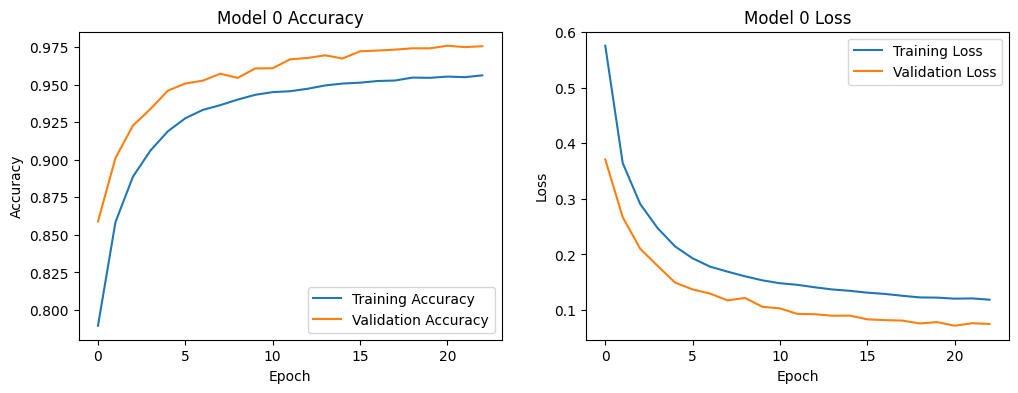


Training Model 1
Model: "tiny_conv_model_small"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 1960)]            0         
                                                                 
 reshape (Reshape)           (None, 49, 40, 1)         0         
                                                                 
 conv (Conv2D)               (None, 25, 20, 8)         648       
                                                                 
 relu (ReLU)                 (None, 25, 20, 8)         0         
                                                                 
 dropout (Dropout)           (None, 25, 20, 8)         0         
                                                                 
 flatten (Flatten)           (None, 4000)              0         
                                                                 
 final_fc (Dense)          

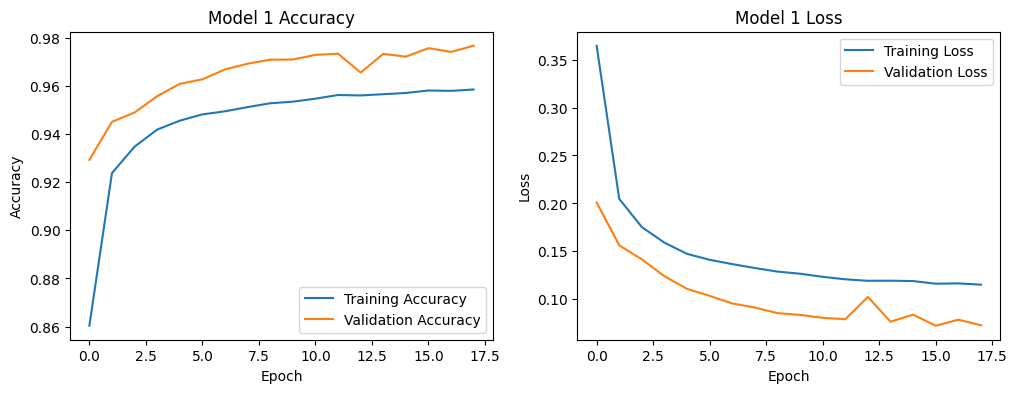

In [92]:
model_list = []
histories = []
sequential_models = True
is_training = True

for i, create_model in enumerate([create_tiny_conv_model, create_tiny_conv_model_small]):
    print(f'\nTraining Model {i}')
    model = create_model(is_training)
    
    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )

    model.summary()


    history = model.fit(
        train_spectrogram_ds,
        validation_data = val_spectrogram_ds,
        epochs=25,  # You can adjust the number of epochs
        callbacks=keras.callbacks.EarlyStopping(verbose=1, patience=2, min_delta=0.001),
        verbose = 1
    )
    model_list.append(model)
    histories.append(history)
    
    plot_training_history(history, i)


In [93]:
for model in model_list:
    model.save(model.name + "base")
    converter = tf.lite.TFLiteConverter.from_saved_model(model.name + "base")  # Path to the SavedModel directory
    tflite_model = converter.convert()
    # Save the TensorFlow Lite model
    with open(model.name + "base.tflite", "wb") as f:
        f.write(tflite_model)


INFO:tensorflow:Assets written to: tiny_conv_modelbase/assets


INFO:tensorflow:Assets written to: tiny_conv_modelbase/assets


INFO:tensorflow:Assets written to: tiny_conv_model_smallbase/assets


INFO:tensorflow:Assets written to: tiny_conv_model_smallbase/assets


In [94]:
for model in model_list:
    test_loss, test_acc = model.evaluate(test_spectrogram_ds, verbose=0)
    print(test_loss, test_acc)

0.07332539558410645 0.976649820804596
0.07162446528673172 0.9774429202079773


## Compile and test models

In [95]:
final_models = model_list #+ new_models

In [96]:
def get_gzipped_tflite_model_size(tflite_model):
    # Write the TFLite model to a temporary file
    with tempfile.NamedTemporaryFile(suffix='.tflite', delete=False) as temp_file:
        temp_file.write(tflite_model)
        model_filename = temp_file.name

    # Compress it as a zip file for size measurement
    with tempfile.NamedTemporaryFile(suffix='.zip', delete=False) as temp_zip:
        zipped_file = temp_zip.name
    with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
        f.write(model_filename, arcname='model.tflite')

    # Get the size of the gzipped model file in KB
    gzipped_size_kb = os.path.getsize(zipped_file) / 1000.0

    # Clean up temporary files
    os.remove(model_filename)
    os.remove(zipped_file)

    return gzipped_size_kb

def get_tflite_model_accuracy(tflite_model, test_dataset):
    # Convert the tf.data.Dataset to NumPy arrays if not already
    # This step assumes test_dataset yields (features, labels)
    X_list, y_list = [], []
    for x_batch, y_batch in test_dataset:
        X_list.append(x_batch.numpy())
        y_list.append(y_batch.numpy())
    X_test = np.concatenate(X_list, axis=0)
    y_test = np.concatenate(y_list, axis=0)

    # Initialize the TFLite interpreter
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    # For quantized models, manually quantize the input data from float to integer
    input_scale, input_zero_point = input_details["quantization"]

    # Reshape test data to match the input shape if necessary
    # Adjust the reshape line based on your model’s input requirements.
    # For example, if input_details['shape'] is [1, height, width, channels],
    # and X_test is [num_samples, height, width, channels], just ensure they match.
    # The snippet provided used a 2D reshape, adjust as appropriate.
    input_shape = input_details['shape']
    # Typically, input_shape[0] is 1 (batch), so we use the rest for reshape
    # Example: If input_shape is [1, 32, 32], then reshape X_test to [X_test.shape[0], 32, 32]
    # Modify this line according to your input shape.
    test_data = X_test.reshape((X_test.shape[0],) + tuple(input_shape[0:2]))

    # Apply quantization scaling to test_data if quantized
    if input_scale > 0:
        test_data = test_data / input_scale + input_zero_point
    test_data = test_data.astype(input_details["dtype"])

    correct_predictions = 0
    for i in range(len(test_data)):
        # Set the input tensor. Note: if the model expects a batch dimension, 
        # you may need test_data[i:i+1] instead of test_data[i]
        interpreter.set_tensor(input_details["index"], test_data[i])
        interpreter.invoke()
        output = interpreter.get_tensor(output_details["index"])[0]

        top_prediction = output.argmax()
        correct_predictions += (top_prediction == y_test[i])

    accuracy = (correct_predictions / len(X_test)) if len(X_test) > 0 else 0.0
    print("tf accuracy: " + str(accuracy) )
    return accuracy


def get_tflite_accuracy(model, test_spectrogram_ds):
    # Convert to TFLite
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()

    # Evaluate the TFLite model's accuracy
    accuracy = get_tflite_model_accuracy(tflite_model, test_spectrogram_ds)

    # Get gzipped size of the TFLite model
    gzipped_size = get_gzipped_tflite_model_size(tflite_model)

    return accuracy, gzipped_size

In [97]:
# Function to reload any serialized models (from bytes) if necessary
def load_if_serialized(model):
    if isinstance(model, bytes):
        # Assuming the model was saved as bytes, use `tf.keras.models.model_from_json` or similar
        raise TypeError("Model is in a serialized bytes format. Please load it as a Keras model before passing.")
    return model

def get_gzipped_model_size(model):
    # Save the model to a temporary file in .keras format
    with tempfile.NamedTemporaryFile(suffix='.keras', delete=False) as temp_file:
        model.save(temp_file.name)
        model_filename = temp_file.name

    # Compress the model file to calculate its gzipped size
    with tempfile.NamedTemporaryFile(suffix='.zip', delete=False) as temp_zip:
        zipped_file = temp_zip.name
    with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
        f.write(model_filename, arcname='model.keras')

    # Get the size of the gzipped model file in kilobytes
    gzipped_size = os.path.getsize(zipped_file) / 1000  # Convert bytes to KB

    # Clean up temporary files
    os.remove(model_filename)
    os.remove(zipped_file)

    return gzipped_size

def plot_size_v_accuracy(models, test_spectrogram_ds):
    # Lists to store the results
    accuracies = []
    model_sizes = []
    model_names = []
    tf_accuracies = []
    tf_model_sizes = []
    # Evaluate each model and store the results
    for i, model in enumerate(models):
        try:
            # Load model if it's in serialized bytes format
            model = load_if_serialized(model)

            # Check if model is a Keras model instance
            #if not isinstance(model, tf.keras.Model):
            #    raise TypeError(f"Model {i} is not a Keras model instance.")

            # Check if the model is compiled by looking for an optimizer
            if model.optimizer is None:
                model.compile(
                    optimizer='adam',
                    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                    metrics=['accuracy']
                )
            
            # Evaluate the model
            test_loss, test_acc = model.evaluate(test_spectrogram_ds, verbose=0)

            # Calculate the gzipped model size
            gzipped_size = get_gzipped_model_size(model)
            
            tf_test_acc, tf_gzipped_size = get_tflite_accuracy(model, test_spectrogram_ds)

            # Print the details
            print(f"Model {i} ({model.name}):")
            print(f"  Gzipped Model Size: {gzipped_size:.2f} KB")
            print(f"  Test Accuracy: {test_acc:.4f}")
            print(f"  TFLite Gzipped Model Size: {tf_gzipped_size:.2f} KB")
            print(f"  TFLite Test Accuracy: {tf_test_acc:.4f}")
            
            # Store the accuracy and model size
            accuracies.append(test_acc)
            model_sizes.append(gzipped_size)
            
            tf_accuracies.append(tf_test_acc)
            tf_model_sizes.append(tf_gzipped_size)
            
            model_names.append(model.name)


        except Exception as e:
            print(f"An error occurred with Model {i}: {e}")

    # Plotting accuracy vs. gzipped model size
    plt.figure(figsize=(10, 6))
    plt.plot(model_sizes, accuracies, marker='o', linestyle='', color='b')
    plt.plot(tf_model_sizes, tf_accuracies, marker='o', linestyle='', color='r')

    plt.ylim(0.0, 1.0)
    
    for i, model_name in enumerate(model_names):
        plt.text(model_sizes[i], accuracies[i], model_name, fontsize=9, ha='right', color = 'b')
        plt.text(tf_model_sizes[i], tf_accuracies[i], f"tf_{model_name}", fontsize=9, ha='right', color = 'r')
        

    # Add labels and title
    plt.xlabel('Gzipped Model Size (KB)')
    plt.ylabel('Test Accuracy')
    plt.title('Model Accuracy vs. Gzipped Model Size')
    plt.grid(True)
    plt.show()

base model test acc: 0.976649820804596


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpe03lxyyk/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpe03lxyyk/assets


tf accuracy: 0.9766498210926261
Model 0 (tiny_conv_model):
  Gzipped Model Size: 71.65 KB
  Test Accuracy: 0.9766
  TFLite Gzipped Model Size: 24.87 KB
  TFLite Test Accuracy: 0.9766
base model test acc: 0.9774429202079773


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp6_ucbntx/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp6_ucbntx/assets


tf accuracy: 0.9774429156368734
Model 1 (tiny_conv_model_small):
  Gzipped Model Size: 192.97 KB
  Test Accuracy: 0.9774
  TFLite Gzipped Model Size: 63.69 KB
  TFLite Test Accuracy: 0.9774


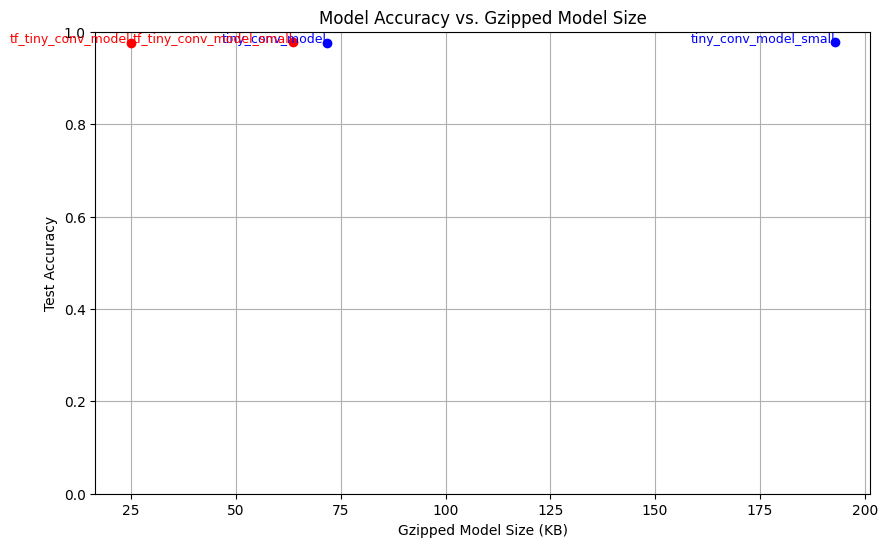

In [98]:
plot_size_v_accuracy(final_models, test_spectrogram_ds)

# Shrinking the model

[deployment on the edge](https://ai.google.dev/edge/litert)

[general model optimizations](https://www.tensorflow.org/model_optimization/guide)

We will start off with pruning

we will aslo try quantization aware training to quantize the model
and we will also try different post-training quantizations

we can also try weight clustering

and finalyl we will try a single workflow with a combination of the previous methods
[collaborative optimizations](https://www.tensorflow.org/model_optimization/guide/combine/collaborative_optimization)


https://blog.tensorflow.org/2024/04/faster-dynamically-quantized-inference-with-xnnpack.html



# Pruning

In [131]:
### Helper functions for pruning

def ds_to_numpy(dataset):
    """Converts a tf.data.Dataset to numpy arrays for data and labels."""
    data = []
    labels = []
    
    for features, label in dataset:
        data.append(features)
        labels.append(label)

    data = tf.concat(data, axis=0).numpy()
    labels = tf.concat(labels, axis=0).numpy()
    
    return data, labels

def print_model_weights_sparsity(model):
    """Prints the sparsity (percentage of zeros) for each layer's weights in the model."""
    for layer in model.layers:
        if isinstance(layer, keras.layers.Wrapper):  # For pruned layers wrapped in the pruning wrapper
            weights = layer.trainable_weights
        else:
            weights = layer.weights
        for weight in weights:
            weight_np = weight.numpy()
            weight_size = weight_np.size
            zero_num = np.count_nonzero(weight_np == 0)
            print(f"{weight.name}: {zero_num / weight_size:.2%} sparsity ({zero_num}/{weight_size})")
            
def sequential_to_functional(sequential_model):
    # Extract the layers from the Sequential model
    inputs = Input(shape=sequential_model.input_shape[1:])
    x = inputs

    # Apply each layer from the Sequential model in sequence
    for layer in sequential_model.layers:
        x = layer(x)
    
    # Create a new functional model
    functional_model = Model(inputs=inputs, outputs=x)
    
    # Copy weights from the Sequential model
    functional_model.set_weights(sequential_model.get_weights())

    print(functional_model)
    
    return functional_model

In [132]:
from tensorflow.keras.models import clone_model
def prune_model(model, train_spectrogram_ds, test_spectrogram_ds):
    """Prunes the given model with optional quantization-aware training (QAT)."""
    # Ensure model is compatible with pruning by converting it to functional if needed
    #model = sequential_to_functional(model)
    
    # Convert datasets to numpy arrays
    train_data, train_labels = ds_to_numpy(train_spectrogram_ds)
    test_data, test_labels = ds_to_numpy(test_spectrogram_ds)
    
    prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

    # Define pruning parameters
    pruning_params = {
        'pruning_schedule': tfmot.sparsity.keras.ConstantSparsity(0.2, begin_step=0, frequency=100)
    }
    
    # Define pruning callbacks
    callbacks = [tfmot.sparsity.keras.UpdatePruningStep()]
    
    pruned_model = prune_low_magnitude(model, **pruning_params)
    
    # Compile the pruned model with a smaller learning rate for fine-tuning
    pruned_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=['accuracy']
    )
    
    # Display model summary
    pruned_model.summary()
    
    # Fine-tune the pruned model
    pruned_model.fit(
        train_data,
        train_labels,
        epochs=3,
        validation_split=0.1,
        callbacks=callbacks
    )
    
    # Strip pruning wrappers for final deployment
    stripped_pruned_model = tfmot.sparsity.keras.strip_pruning(pruned_model)


    # Apply pruning
    #if qat:
        # Quantization-aware training with pruning
    #    quant_aware_annotate_model = tfmot.quantization.keras.quantize_annotate_model(model)
    #    pruned_model = tfmot.quantization.keras.quantize_apply(
    #        quant_aware_annotate_model,
    #        tfmot.experimental.combine.Default8BitPrunePreserveQuantizeScheme()
    #    )
    

    # Check sparsity levels
    print_model_weights_sparsity(stripped_pruned_model)

    # Evaluate the pruned model on test data
    _, pruned_model_accuracy = pruned_model.evaluate(test_data, test_labels, verbose=0)
    print("Pruned test accuracy:", pruned_model_accuracy)

    return stripped_pruned_model

In [133]:
# Prune models and store in basic_pruned_models
basic_pruned_models = []

for model in final_models:
    # Clone the model to avoid modifying the original model
    model_name = model.name
    cloned_model = clone_model(model)
    cloned_model.set_weights(model.get_weights())  # Copy weights to the cloned model
    cloned_model._name = "pruned_"+model_name
    # Prune the cloned model
    pruned_model = prune_model(cloned_model, train_spectrogram_ds, test_spectrogram_ds)
    basic_pruned_models.append(pruned_model)

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Model: "pruned_tiny_conv_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 1960)]            0         
                                                                 
 prune_low_magnitude_reshape  (None, 49, 40, 1)        1         
  (PruneLowMagnitude)                                            
                                                                 
 prune_low_magnitude_conv1 (  (None, 25, 20, 8)        1290      
 PruneLowMagnitude)                                              
                                                                 
 prune_low_magnitude_relu1 (  (None, 25, 20, 8)        1         
 PruneLowMagnitude)                                              
                                                                 
 prune_low_magnitude_dropout  (None, 25, 20, 8)        1         
 1 (PruneLowMagnitude)                      

base model test acc: 0.9773876070976257


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpul7mkybq/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpul7mkybq/assets


tf accuracy: 0.9773875834593677
Model 0 (pruned_tiny_conv_model):
  Gzipped Model Size: 23.18 KB
  Test Accuracy: 0.9774
  TFLite Gzipped Model Size: 21.69 KB
  TFLite Test Accuracy: 0.9774
base model test acc: 0.9780331254005432


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpy3k9qa7b/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpy3k9qa7b/assets


tf accuracy: 0.9780331255302667
Model 1 (pruned_tiny_conv_model_small):
  Gzipped Model Size: 57.00 KB
  Test Accuracy: 0.9780
  TFLite Gzipped Model Size: 55.15 KB
  TFLite Test Accuracy: 0.9780


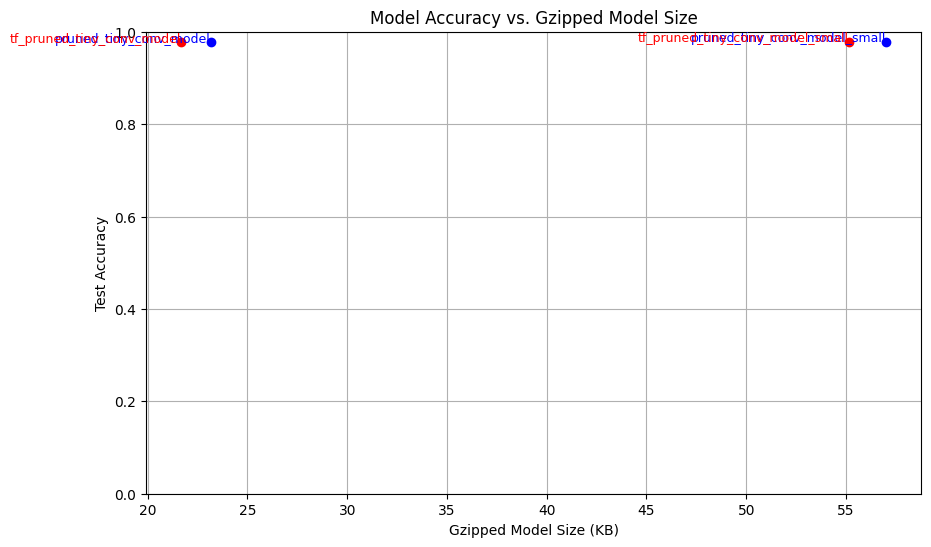

In [134]:
plot_size_v_accuracy(basic_pruned_models, test_spectrogram_ds)

In [141]:

for model in basic_pruned_models:
    model.save(model.name + "p")
    converter = tf.lite.TFLiteConverter.from_saved_model(model.name + "p")  # Path to the SavedModel directory
    tflite_model = converter.convert()
    # Save the TensorFlow Lite model
    with open(model.name + "p.tflite", "wb") as f:
        f.write(tflite_model)


INFO:tensorflow:Assets written to: pruned_tiny_conv_modelp/assets


INFO:tensorflow:Assets written to: pruned_tiny_conv_modelp/assets


INFO:tensorflow:Assets written to: pruned_tiny_conv_model_smallp/assets


INFO:tensorflow:Assets written to: pruned_tiny_conv_model_smallp/assets


# Weight Clustering

In [146]:
from tensorflow_model_optimization.python.core.clustering.keras.experimental import (
    cluster,
)

In [147]:
def cluster_model(model, train_spectrogram_ds, test_spectrogram_ds):
    train_data, train_labels = ds_to_numpy(train_spectrogram_ds)
    test_data, test_labels = ds_to_numpy(test_spectrogram_ds)
    
    cluster_weights = tfmot.clustering.keras.cluster_weights
    CentroidInitialization = tfmot.clustering.keras.CentroidInitialization

    cluster_weights = cluster.cluster_weights

    clustering_params = {
      'number_of_clusters': 10,
      'cluster_centroids_init': CentroidInitialization.KMEANS_PLUS_PLUS,
      'preserve_sparsity': True
    }

    sparsity_clustered_model = cluster_weights(model, **clustering_params)

    sparsity_clustered_model.compile(optimizer='adam',
                  loss=keras.losses.SparseCategoricalCrossentropy(),
                  metrics=['accuracy'])

    print('Train sparsity preserving clustering model:')
    sparsity_clustered_model.fit(train_data, train_labels,epochs=3, validation_split=0.1)
    
    stripped_clustered_model = tfmot.clustering.keras.strip_clustering(sparsity_clustered_model)

    return stripped_clustered_model


In [148]:
pruned_clustered_models = []

for model in basic_pruned_models:
    # Clone the model to avoid modifying the original model
    model_name = model.name
    cloned_model = clone_model(model)
    cloned_model.set_weights(model.get_weights())  # Copy weights to the cloned model
    cloned_model._name = "clustered_"+model_name
    clustered_model = cluster_model(cloned_model, train_spectrogram_ds, test_spectrogram_ds)
    pruned_clustered_models.append(clustered_model)


Train sparsity preserving clustering model:
Epoch 1/3
4575/4575 [==============================] - 19s 4ms/step - loss: 0.0742 - accuracy: 0.9740 - val_loss: 0.0693 - val_accuracy: 0.9752
Epoch 2/3
4575/4575 [==============================] - 17s 4ms/step - loss: 0.0665 - accuracy: 0.9766 - val_loss: 0.0662 - val_accuracy: 0.9773
Epoch 3/3
4575/4575 [==============================] - 17s 4ms/step - loss: 0.0621 - accuracy: 0.9785 - val_loss: 0.0680 - val_accuracy: 0.9782
Train sparsity preserving clustering model:
Epoch 1/3
4575/4575 [==============================] - 15s 3ms/step - loss: 0.0677 - accuracy: 0.9773 - val_loss: 0.0589 - val_accuracy: 0.9795
Epoch 2/3
4575/4575 [==============================] - 14s 3ms/step - loss: 0.0605 - accuracy: 0.9800 - val_loss: 0.0818 - val_accuracy: 0.9721
Epoch 3/3
4575/4575 [==============================] - 13s 3ms/step - loss: 0.0545 - accuracy: 0.9818 - val_loss: 0.0833 - val_accuracy: 0.9714


base model test acc: 0.9768158197402954


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp3wu29_4d/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp3wu29_4d/assets


tf accuracy: 0.9768158176251429
Model 0 (clustered_pruned_tiny_conv_model):
  Gzipped Model Size: 6.86 KB
  Test Accuracy: 0.9768
  TFLite Gzipped Model Size: 5.61 KB
  TFLite Test Accuracy: 0.9768
base model test acc: 0.9686266779899597


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp6lx8ruj_/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp6lx8ruj_/assets


tf accuracy: 0.9686266553543104
Model 1 (clustered_pruned_tiny_conv_model_small):
  Gzipped Model Size: 11.57 KB
  Test Accuracy: 0.9686
  TFLite Gzipped Model Size: 9.64 KB
  TFLite Test Accuracy: 0.9686


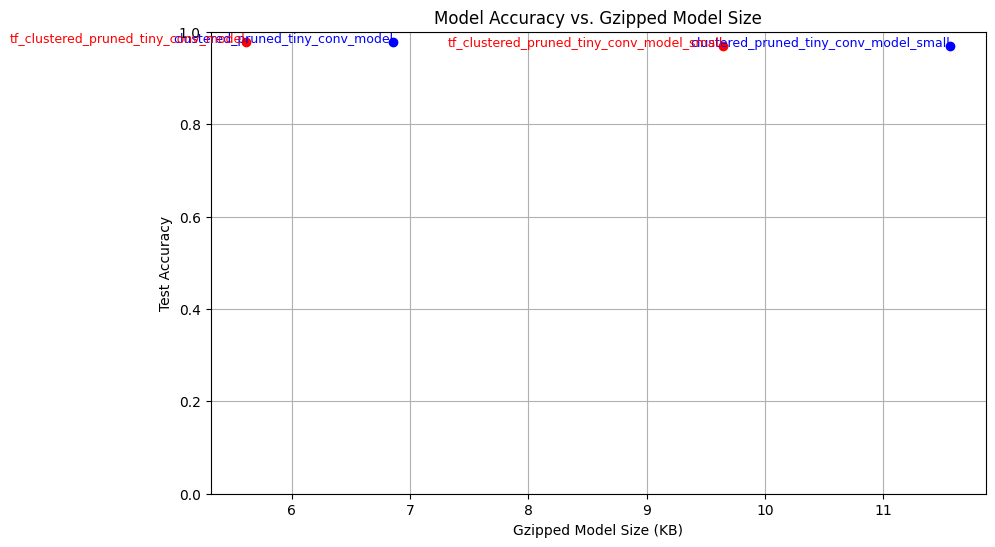

In [149]:
plot_size_v_accuracy(pruned_clustered_models, test_spectrogram_ds)

In [167]:

for model in pruned_clustered_models:
    model.save(model.name + "pc")
    converter = tf.lite.TFLiteConverter.from_saved_model(model.name + "pc")  # Path to the SavedModel directory
    tflite_model = converter.convert()
    # Save the TensorFlow Lite model
    with open(model.name + "pc.tflite", "wb") as f:
        f.write(tflite_model)



INFO:tensorflow:Assets written to: clustered_pruned_tiny_conv_modelpc/assets


INFO:tensorflow:Assets written to: clustered_pruned_tiny_conv_modelpc/assets


INFO:tensorflow:Assets written to: clustered_pruned_tiny_conv_model_smallpc/assets


INFO:tensorflow:Assets written to: clustered_pruned_tiny_conv_model_smallpc/assets


## Pruning preserving quantization aware training (PQAT) and Sparsity and cluster preserving quantization aware training (PCQAT)
https://www.tensorflow.org/model_optimization/guide/combine/pqat_example
https://www.tensorflow.org/model_optimization/guide/combine/pcqat_example

## Sparsity and cluster preserving quantization aware training
https://www.tensorflow.org/model_optimization/guide/combine/pcqat_example

# Quantize models

https://www.tensorflow.org/model_optimization/guide

https://blog.tensorflow.org/2024/04/faster-dynamically-quantized-inference-with-xnnpack.html


we can also add some weight clustering?

## quantization aware training quantized models with or without pruning
https://www.tensorflow.org/model_optimization/guide/quantization/training_example

https://www.tensorflow.org/model_optimization/guide/quantization/training_comprehensive_guide#quantize_some_layers

In [159]:
def print_model_weights_sparsity(model):
    for layer in model.layers:
        if isinstance(layer, keras.layers.Wrapper):
            weights = layer.trainable_weights
        else:
            weights = layer.weights
        for weight in weights:
            if "kernel" not in weight.name or "centroid" in weight.name:
                continue
            weight_size = weight.numpy().size
            zero_num = np.count_nonzero(weight == 0)
            print(
                f"{weight.name}: {zero_num/weight_size:.2%} sparsity ",
                f"({zero_num}/{weight_size})",
            )

def print_model_weight_clusters(model):
    for layer in model.layers:
        if isinstance(layer, keras.layers.Wrapper):
            weights = layer.trainable_weights
        else:
            weights = layer.weights
        for weight in weights:
            # ignore auxiliary quantization weights
            if "quantize_layer" in weight.name:
                continue
            if "kernel" in weight.name:
                unique_count = len(np.unique(weight))
                print(
                    f"{layer.name}/{weight.name}: {unique_count} clusters "
                )

# The cells below int8 quantize and deploy the model

In [121]:
 def deploy(model, save = True):
    ############################################
    # Step 3: Save the Model as a SavedModel
    ############################################
    saved_model_path = f"{model.name}_deployable"
    model.save(saved_model_path, save_format="tf")

    ############################################
    # Step 4: Create a Representative Dataset Function
    ############################################
    # The representative dataset provides samples to the converter
    # so it can calibrate integer scales and zero points.
    X, y = ds_to_numpy(train_spectrogram_ds)
    def representative_dataset_generator():
        for i in range(len(X)):
            # Generate random image-like data in a similar range as your real input
            # Here inputs are assumed to be normalized [0,1], but if not, adjust accordingly.
            data = np.array(X[i].flatten(), dtype=np.float32).reshape(1, 1960)
            yield [data]

    ############################################
    # Step 5: Convert the Model to TFLite with Full Integer Quantization
    ############################################
    converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_path)

    # Enable optimizations to ensure quantization is done
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    # Provide the representative dataset for calibration
    converter.representative_dataset = representative_dataset_generator

    # Set input and output inference types to uint8
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    # This will produce a fully quantized model (uint8)
    tflite_quant_model = converter.convert()

    # Save the quantized model to a file
    tf_path = f"{model.name}_deployable_int8.tflite"
    with open(tf_path, "wb") as f:
        f.write(tflite_quant_model)

    size = get_gzipped_model_file_size(tf_path)
    print("Model size: " + str(size))
    ############################################
    # Verification (Optional)
    ############################################
    # Load the TFLite model and check the input type
    interpreter = tf.lite.Interpreter(model_path=tf_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    print("Input details:", input_details)
    print("Output details:", output_details)
    
    if save:
        !xxd -i {tf_path} > {model.name}_deployable.cc

    return interpreter

In [168]:
for model in pruning_quantized_qat_models:
    deploy(model)

INFO:tensorflow:Assets written to: qat_pruned_tiny_conv_model_deployable/assets


INFO:tensorflow:Assets written to: qat_pruned_tiny_conv_model_deployable/assets
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Model size: 7.482
Input details: [{'name': 'serving_default_input:0', 'index': 0, 'shape': array([   1, 1960], dtype=int32), 'shape_signature': array([  -1, 1960], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.003921568859368563, -128), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall:0', 'index': 21, 'shape': array([1, 4], dtype=int32), 'shape_signature': array([-1,  4], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


INFO:tensorflow:Assets written to: pcqat_pruned_tiny_conv_model_deployable/assets


INFO:tensorflow:Assets written to: pcqat_pruned_tiny_conv_model_deployable/assets
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


...

INFO:tensorflow:Assets written to: qat_pruned_tiny_conv_model_small_deployable/assets
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Model size: 14.503
Input details: [{'name': 'serving_default_input:0', 'index': 0, 'shape': array([   1, 1960], dtype=int32), 'shape_signature': array([  -1, 1960], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.003921568859368563, -128), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall:0', 'index': 18, 'shape': array([1, 4], dtype=int32), 'shape_signature': array([-1,  4], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


INFO:tensorflow:Assets written to: pcqat_pruned_tiny_conv_model_small_deployable/assets


INFO:tensorflow:Assets written to: pcqat_pruned_tiny_conv_model_small_deployable/assets
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Model size: 14.259
Input details: [{'name': 'serving_default_input:0', 'index': 0, 'shape': array([   1, 1960], dtype=int32), 'shape_signature': array([  -1, 1960], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.003921568859368563, -128), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall:0', 'index': 18, 'shape': array([1, 4], dtype=int32), 'shape_signature': array([-1,  4], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


In [169]:
def dequantize_output_data(data: np.ndarray,
                           output_details: dict) -> np.ndarray:
  """Dequantize the model output

  Args:
      data: integer data to be dequantized
      output_details: TFLM interpreter model output details

  Returns:
      np.ndarray: dequantized data as float32 dtype
  """
  output_quantization_parameters = output_details['quantization_parameters']
  output_scale = output_quantization_parameters['scales'][0]
  output_zero_point = output_quantization_parameters['zero_points'][0]
  # Caveat: tflm_output_quant need to be converted to float to avoid integer
  # overflow during dequantization
  # e.g., (tflm_output_quant -output_zero_point) and
  # (tflm_output_quant + (-output_zero_point))
  # can produce different results (int8 calculation)
  return output_scale * (data.astype(np.float32) - output_zero_point)

In [170]:
def quantize_input_data(data, input_details):
    """quantize the input data using scale and zero point

    Args:
      data (np.array in float): input data for the interpreter
      input_details : output of get_input_details from the tflm interpreter.

    Returns:
      np.ndarray: quantized data as int8 dtype
    """
    # Get input quantization parameters
    data_type = input_details['dtype']
    input_quantization_parameters = input_details['quantization_parameters']
    input_scale, input_zero_point = input_quantization_parameters['scales'][
        0], input_quantization_parameters['zero_points'][0]
    # quantize the input data
    data = data / input_scale + input_zero_point
    return data.astype(data_type)

In [ ]:
correct_predictions = 0
for i in range(len(test_data)):
    interpreter.set_tensor(input_details["index"], test_data[i])
    interpreter.invoke()
    output = interpreter.get_tensor(output_details["index"])[0]
    top_prediction = output.argmax()
    correct_predictions += (top_prediction == y_test[i])

print('model accuracy is %f%% (Number of test samples=%d)' % (
    (correct_predictions * 100) / len(X_test), len(X_test)))

In [187]:
def get_int8_tflite_accuracy(tflite_model_path, test_spectrogram_ds, CFM = False):
    # Convert test dataset to NumPy arrays
    X, y = ds_to_numpy(test_spectrogram_ds)

    predictions = []
    interpreter = tf.lite.Interpreter(model_path=tflite_model_path)
    interpreter.allocate_tensors()
    
    
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]
    
    print(f"input type: {input_details['dtype']}")
    print(f"features type: {X[0].dtype}")
    
    for i, features in enumerate(X):
        # Quantize the input if the model expects quantized input
        if input_details['dtype'] != np.float32 and features.dtype == np.float32:
            features = quantize_input_data(features, input_details)
        
        # Reshape features to match the model input shape
        flattened_features = features.flatten().reshape(input_details['shape'])
        interpreter.set_tensor(input_details['index'], flattened_features)
        interpreter.invoke()

        # Get the output tensor
        tflm_output = interpreter.get_tensor(output_details['index'])

        # If the model is quantized, dequantize the output
        if output_details['dtype'] != np.float32:
            tflm_output = dequantize_output_data(tflm_output, output_details)
        
        #print(str(tflm_output), " : ", str(y[i]))
        # Store the prediction
        predictions.append(np.argmax(tflm_output))
        
    # Calculate accuracy
    accuracy = np.mean(np.array(predictions) == y)
    print(f"TFLite INT8 model accuracy: {accuracy:.4f}")

    if CFM:
        # Create confusion matrix
        cm = confusion_matrix(y, predictions)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
        disp.plot(cmap='viridis', xticks_rotation='vertical')
        plt.title("Confusion Matrix")
        plt.show()

    return accuracy

input type: <class 'numpy.int8'>
features type: float32
TFLite INT8 model accuracy: 0.9748


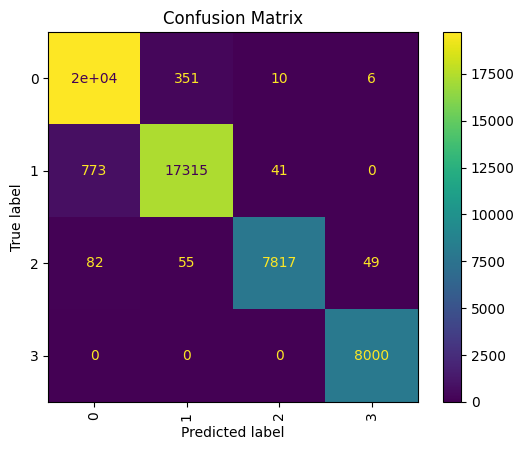

In [188]:
for model in pruning_quantized_qat_models[:1]:
    filename = "/"+model.name+"_deployable_int8.tflite"
    tf_model_path = root_directory + filename
    get_int8_tflite_accuracy(tf_model_path, test_spectrogram_ds, True)

In [157]:
#import tensorflow_model_optimization as tfmot

#quantization aware training with int8 weights and uint8 activations.
def qat(model, save = False, deployable = False):
    
    cloned_model = clone_model(model)
    cloned_model.set_weights(model.get_weights())  # Copy weights to the cloned model
    #cloned_model._name = "clustered_"+model_name
            
    # QAT
    qat_model = tfmot.quantization.keras.quantize_model(cloned_model)

    qat_model.compile(optimizer='adam',
                  loss=keras.losses.SparseCategoricalCrossentropy(),
                  metrics=['accuracy'])
    print('Train qat model:')
    
    num_batches = tf.data.experimental.cardinality(train_spectrogram_ds).numpy()

    qat_model.fit(train_spectrogram_ds, batch_size=64, epochs=1, validation_data=val_spectrogram_ds)
    qat_model._name = "qat_"+cloned_model.name
    
    # PCQAT
    quant_aware_annotate_model = tfmot.quantization.keras.quantize_annotate_model(
                  cloned_model)
    pcqat_model = tfmot.quantization.keras.quantize_apply(
                  quant_aware_annotate_model,
                  tfmot.experimental.combine.Default8BitClusterPreserveQuantizeScheme(preserve_sparsity=True))

    pcqat_model.compile(optimizer='adam',
                  loss=keras.losses.SparseCategoricalCrossentropy(),
                  metrics=['accuracy'])
    print('Train pcqat model:')
    pcqat_model.fit(train_spectrogram_ds, batch_size=64, epochs=1, validation_data=val_spectrogram_ds)
    pcqat_model._name = "pcqat_"+cloned_model.name
    
    print("QAT Model clusters:")
    print_model_weight_clusters(qat_model)
    print("\nQAT Model sparsity:")
    print_model_weights_sparsity(qat_model)
    print("\nPCQAT Model clusters:")
    print_model_weight_clusters(pcqat_model)
    print("\nPCQAT Model sparsity:")
    print_model_weights_sparsity(pcqat_model)
    
    if save:
        model_filename = model.name
               
        if not deployable:
            # QAT model
            converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
            converter.optimizations = [tf.lite.Optimize.DEFAULT]
            qat_tflite_model = converter.convert()
            qat_model_file = f'{model_filename}_qat_model.tflite'
            # Save the model.
            with open(qat_model_file, 'wb') as f:
                f.write(qat_tflite_model)

            # PCQAT model
            converter = tf.lite.TFLiteConverter.from_keras_model(pcqat_model)
            converter.optimizations = [tf.lite.Optimize.DEFAULT]
            pcqat_tflite_model = converter.convert()
            pcqat_model_file = f'{model_filename}_pcqat_model.tflite'
            # Save the model.
            with open(pcqat_model_file, 'wb') as f:
                f.write(pcqat_tflite_model)
                
                
        if deployable:
            deploy(qat_model)
            deploy(pcqat_model)
                
            
            ''' 
            def representative_dataset():
                for spectrogram, _ in train_spectrogram_ds:
                    spectrogram = np.array(spectrogram, dtype=np.float32)
                    for spec in spectrogram:
                        spec_re = spec.reshape(1, 1960)
                        yield [spec_re]
                        
            # QAT model
            converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
            converter.optimizations = [tf.lite.Optimize.DEFAULT]
            converter.representative_dataset = representative_dataset
            converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
            converter.inference_input_type = tf.int8
            converter.inference_output_type = tf.int8
            qat_tflite_model = converter.convert()
            qat_model_file = f'{model_filename}_qat_model.tflite'
            # Save the model.
            with open(qat_model_file, 'wb') as f:
                f.write(qat_tflite_model)

            # PCQAT model
            converter = tf.lite.TFLiteConverter.from_keras_model(pcqat_model)
            converter.optimizations = [tf.lite.Optimize.DEFAULT]
            converter.representative_dataset = representative_dataset
            converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
            converter.inference_input_type = tf.int8
            converter.inference_output_type = tf.int8
            pcqat_tflite_model = converter.convert()
            pcqat_model_file = f'{model_filename}_pcqat_model.tflite'
            # Save the model.
            with open(pcqat_model_file, 'wb') as f:
                f.write(pcqat_tflite_model)
            '''


    return qat_model, pcqat_model

In [155]:
'''
# Evaluate the TFLite quantized model
def evaluate_tflite_model(interpreter, dataset):
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    total_samples = 0
    correct_predictions = 0

    for spectrograms, labels in dataset:
        input_data = spectrograms.numpy().astype('uint8')
        interpreter.set_tensor(input_details[0]['index'], input_data)
        interpreter.invoke()
        predictions = interpreter.get_tensor(output_details[0]['index'])
        predicted_labels = tf.argmax(predictions, axis=1)
        correct_predictions += tf.reduce_sum(tf.cast(predicted_labels == labels, tf.int32)).numpy()
        total_samples += labels.shape[0]

    accuracy = correct_predictions / total_samples
    return accuracy
'''

"\n# Evaluate the TFLite quantized model\ndef evaluate_tflite_model(interpreter, dataset):\n    input_details = interpreter.get_input_details()\n    output_details = interpreter.get_output_details()\n\n    total_samples = 0\n    correct_predictions = 0\n\n    for spectrograms, labels in dataset:\n        input_data = spectrograms.numpy().astype('uint8')\n        interpreter.set_tensor(input_details[0]['index'], input_data)\n        interpreter.invoke()\n        predictions = interpreter.get_tensor(output_details[0]['index'])\n        predicted_labels = tf.argmax(predictions, axis=1)\n        correct_predictions += tf.reduce_sum(tf.cast(predicted_labels == labels, tf.int32)).numpy()\n        total_samples += labels.shape[0]\n\n    accuracy = correct_predictions / total_samples\n    return accuracy\n"

In [160]:
quantized_qat_models = []
pruning_quantized_qat_models = []
pruning_clustered_quantized_qat_models = []

# Do qat with non-pruned models
for model in final_models:
    qat_tflite_model, pcqat_tflite_model = qat(model, save = True, deployable = False)
    quantized_qat_models.append(qat_tflite_model)
    quantized_qat_models.append(pcqat_tflite_model)

# Do qat with pruned models
for model in basic_pruned_models:
    pruned_qat_tflite_model, pruned_pcqat_tflite_model = qat(model, save = True, deployable = False)
    pruning_quantized_qat_models.append(pruned_qat_tflite_model)
    pruning_quantized_qat_models.append(pruned_pcqat_tflite_model)

# Do qat with pruned clustered models
for model in pruned_clustered_models:
    pruned_clustered_qat_tflite_model, pruned_clustered_pcqat_tflite_model = qat(model, save = True, deployable = True)
    pruning_clustered_quantized_qat_models.append(pruned_clustered_qat_tflite_model)
    pruning_clustered_quantized_qat_models.append(pruned_clustered_pcqat_tflite_model)



Train qat model:
2542/2542 [==============================] - 10s 4ms/step - loss: 0.1241 - accuracy: 0.9524 - val_loss: 0.0788 - val_accuracy: 0.9720


Train pcqat model:


2542/2542 [==============================] - 22s 8ms/step - loss: 0.1243 - accuracy: 0.9534 - val_loss: 0.0783 - val_accuracy: 0.9692
QAT Model clusters:
quant_conv1/conv1/kernel:0: 640 clusters 
quant_conv2/conv2/kernel:0: 5120 clusters 
quant_final_fc/final_fc/kernel:0: 384 clusters 

QAT Model sparsity:
conv1/kernel:0: 0.00% sparsity  (0/640)
conv2/kernel:0: 0.00% sparsity  (0/5120)
final_fc/kernel:0: 0.00% sparsity  (0/384)

PCQAT Model clusters:
quant_conv1/conv1/kernel:0: 640 clusters 
quant_conv2/conv2/kernel:0: 5120 clusters 
quant_final_fc/final_fc/kernel:0: 274 clusters 

PCQAT Model sparsity:
conv1/kernel:0: 0.00% sparsity  (0/640)
conv2/kernel:0: 0.00% sparsity  (0/5120)
final_fc/kernel:0: 0.00% sparsity  (0/384)


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmptni7cvxy/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmptni7cvxy/assets
/share/pkg.7/tensorflow/2.11.0/install/lib/SCC/../python3.10/site-packages/tensorflow/lite/python/convert.py:765: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


...

INFO:tensorflow:Assets written to: qat_clustered_pruned_tiny_conv_model_small_deployable/assets
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Model size: 13.116
Input details: [{'name': 'serving_default_input:0', 'index': 0, 'shape': array([   1, 1960], dtype=int32), 'shape_signature': array([  -1, 1960], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.003921568859368563, -128), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall:0', 'index': 18, 'shape': array([1, 4], dtype=int32), 'shape_signature': array([-1,  4], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


INFO:tensorflow:Assets written to: pcqat_clustered_pruned_tiny_conv_model_small_deployable/assets


INFO:tensorflow:Assets written to: pcqat_clustered_pruned_tiny_conv_model_small_deployable/assets
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


Model size: 7.354
Input details: [{'name': 'serving_default_input:0', 'index': 0, 'shape': array([   1, 1960], dtype=int32), 'shape_signature': array([  -1, 1960], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.003921568859368563, -128), 'quantization_parameters': {'scales': array([0.00392157], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall:0', 'index': 18, 'shape': array([1, 4], dtype=int32), 'shape_signature': array([-1,  4], dtype=int32), 'dtype': <class 'numpy.int8'>, 'quantization': (0.00390625, -128), 'quantization_parameters': {'scales': array([0.00390625], dtype=float32), 'zero_points': array([-128], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


base model test acc: 0.9731823205947876


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpbr6l9i20/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpbr6l9i20/assets


tf accuracy: 0.9731823379689402
Model 0 (qat_tiny_conv_model):
  Gzipped Model Size: 70.50 KB
  Test Accuracy: 0.9732
  TFLite Gzipped Model Size: 25.93 KB
  TFLite Test Accuracy: 0.9732
base model test acc: 0.971005916595459


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmprix0x5ms/assets


...

INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpqpiz8cwj/assets


tf accuracy: 0.9721125825371648
Model 2 (qat_tiny_conv_model_small):
  Gzipped Model Size: 192.90 KB
  Test Accuracy: 0.9721
  TFLite Gzipped Model Size: 42.44 KB
  TFLite Test Accuracy: 0.9721
base model test acc: 0.9730901122093201


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp008hje6f/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp008hje6f/assets


tf accuracy: 0.9730901176730975
Model 3 (pcqat_tiny_conv_model_small):
  Gzipped Model Size: 192.36 KB
  Test Accuracy: 0.9731
  TFLite Gzipped Model Size: 42.48 KB
  TFLite Test Accuracy: 0.9731


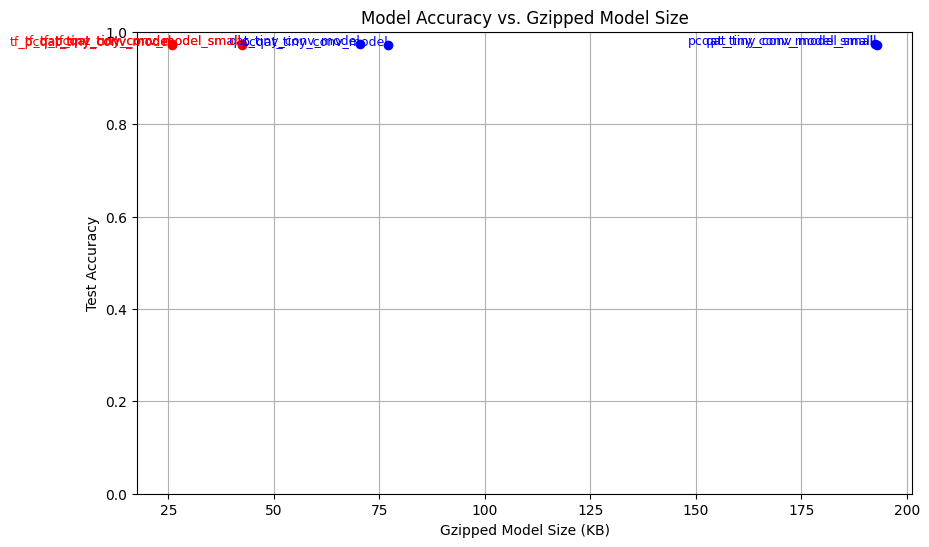

In [161]:
plot_size_v_accuracy(quantized_qat_models, test_spectrogram_ds)

base model test acc: 0.9749161005020142


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpwu2g82iy/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpwu2g82iy/assets


tf accuracy: 0.9749160795307832
Model 0 (qat_pruned_tiny_conv_model):
  Gzipped Model Size: 69.19 KB
  Test Accuracy: 0.9749
  TFLite Gzipped Model Size: 24.76 KB
  TFLite Test Accuracy: 0.9749
base model test acc: 0.9693275094032288


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp857to2u9/assets


...

INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmps8lbann3/assets


tf accuracy: 0.9746578627024235
Model 2 (qat_pruned_tiny_conv_model_small):
  Gzipped Model Size: 192.64 KB
  Test Accuracy: 0.9747
  TFLite Gzipped Model Size: 42.52 KB
  TFLite Test Accuracy: 0.9747
base model test acc: 0.9770925045013428


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp699c5ycw/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp699c5ycw/assets


tf accuracy: 0.9770924785126711
Model 3 (pcqat_pruned_tiny_conv_model_small):
  Gzipped Model Size: 169.21 KB
  Test Accuracy: 0.9771
  TFLite Gzipped Model Size: 41.86 KB
  TFLite Test Accuracy: 0.9771


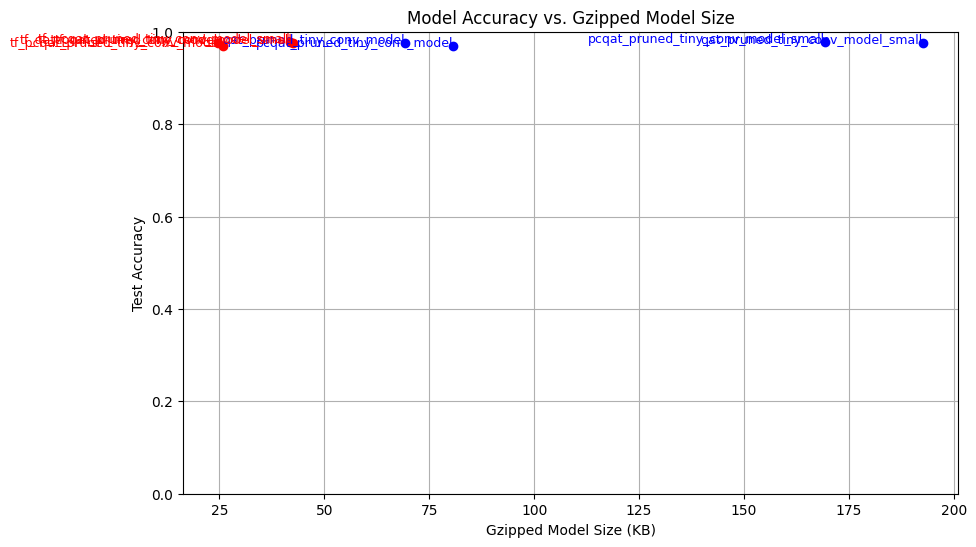

In [162]:
plot_size_v_accuracy(pruning_quantized_qat_models, test_spectrogram_ds)

base model test acc: 0.9771662354469299


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp8esrg2rm/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmp8esrg2rm/assets


tf accuracy: 0.9771662547493453
Model 0 (qat_clustered_pruned_tiny_conv_model):
  Gzipped Model Size: 68.39 KB
  Test Accuracy: 0.9772
  TFLite Gzipped Model Size: 24.03 KB
  TFLite Test Accuracy: 0.9772
base model test acc: 0.9767605066299438


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpg1kihrdl/assets


...

INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmppujed6i9/assets


tf accuracy: 0.9779593492935925
Model 2 (qat_clustered_pruned_tiny_conv_model_small):
  Gzipped Model Size: 191.69 KB
  Test Accuracy: 0.9780
  TFLite Gzipped Model Size: 37.69 KB
  TFLite Test Accuracy: 0.9780
base model test acc: 0.9716330170631409


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpjpbx37fq/assets


INFO:tensorflow:Assets written to: /scratch/1531788.1.academic-gpu/tmpjpbx37fq/assets


tf accuracy: 0.9716330369987827
Model 3 (pcqat_clustered_pruned_tiny_conv_model_small):
  Gzipped Model Size: 190.59 KB
  Test Accuracy: 0.9716
  TFLite Gzipped Model Size: 19.88 KB
  TFLite Test Accuracy: 0.9716


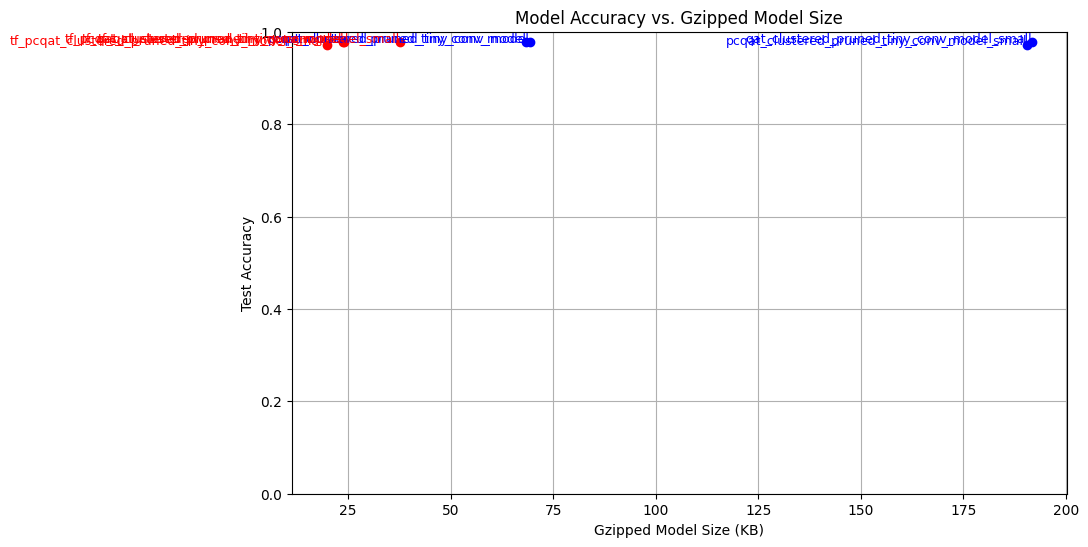

In [163]:
plot_size_v_accuracy(pruning_clustered_quantized_qat_models, test_spectrogram_ds)

In [166]:
def get_gzipped_model_file_size(file):
  # It returns the size of the gzipped model in kilobytes.
  _, zipped_file = tempfile.mkstemp('.zip')
  with zipfile.ZipFile(zipped_file, 'w', compression=zipfile.ZIP_DEFLATED) as f:
    f.write(file)

  return os.path.getsize(zipped_file)/1000


## Post training quantization

https://ai.google.dev/edge/litert/models/post_training_quant

In [184]:
# Function to quantize the models using TensorFlow Lite Micro with different granularities
def quantize_model(model, optimization_strategy):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    if optimization_strategy == 'weight':
        # Quantize only weights
        converter.target_spec.supported_types = [tf.float16]
    elif optimization_strategy == 'full':
        # Full integer quantization
        def representative_dataset():
            for spectrogram, _ in train_spectrogram_ds:
                spectrogram = np.array(spectrogram, dtype=np.float32)
                yield [spectrogram]
        converter.representative_dataset = representative_dataset
        #converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.uint8
        converter.inference_output_type = tf.uint8
    elif optimization_strategy == 'dynamic':
        # Dynamic range quantization
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
    else:
        raise ValueError("Unsupported optimization strategy. Use 'weight', 'full', or 'dynamic'.")
    tflite_model = converter.convert()
    return tflite_model

In [185]:
# Function to quantize the models using post-training integer quantization with int16 activations and int8 weights
def quantize_model_int16x8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    def representative_dataset():
        for spectrogram, _ in train_spectrogram_ds.take(100):
            spectrogram = np.array(spectrogram, dtype=np.float32)
            yield [spectrogram]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.EXPERIMENTAL_TFLITE_BUILTINS_ACTIVATIONS_INT16_WEIGHTS_INT8]
    converter.inference_input_type = tf.int16
    converter.inference_output_type = tf.int16
    tflite_model = converter.convert()
    return tflite_model

In [186]:
for model in final_models:
    print("Model name:", model.name)

Model name: tiny_conv_model
Model name: tiny_conv_model_small


In [187]:
# Quantize each trained model with different granularities and save them
quantization_strategies = ['weight', 'full', 'dynamic']
quantization_strategies = ['full']

for i, model in enumerate(final_models):
    for strategy in quantization_strategies:
        print(f'Quantizing Model {model.name} with {strategy} strategy')
        tflite_model = quantize_model(model, strategy)
        model_filename = f'{model.name}_{strategy}_quantized.tflite'
        with open(model_filename, 'wb') as f:
            f.write(tflite_model)
        print(f'Model {i} quantized with {strategy} strategy and saved as {model_filename}')

    # Quantize using post-training integer quantization with int16 activations and int8 weights
    #print(f'Quantizing Model {i} with int16 activations and int8 weights')
    #tflite_model_int16x8 = quantize_model_int16x8(model)
    #model_filename_int16x8 = f'model_{model}_int16x8_quantized.tflite'
    #with open(model_filename_int16x8, 'wb') as f:
    #    f.write(tflite_model_int16x8)
    #print(f'Model {i} quantized with int16 activations and int8 weights and saved as {model_filename_int16x8}')

Quantizing Model tiny_conv_model with full strategy


INFO:tensorflow:Assets written to: /scratch/1483148.1.academic-gpu/tmpss8zhw47/assets


INFO:tensorflow:Assets written to: /scratch/1483148.1.academic-gpu/tmpss8zhw47/assets
/share/pkg.7/tensorflow/2.11.0/install/lib/SCC/../python3.10/site-packages/tensorflow/lite/python/convert.py:765: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "
fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


Model 0 quantized with full strategy and saved as tiny_conv_model_full_quantized.tflite
Quantizing Model tiny_conv_model_small with full strategy


INFO:tensorflow:Assets written to: /scratch/1483148.1.academic-gpu/tmptbm0nnq8/assets


INFO:tensorflow:Assets written to: /scratch/1483148.1.academic-gpu/tmptbm0nnq8/assets
/share/pkg.7/tensorflow/2.11.0/install/lib/SCC/../python3.10/site-packages/tensorflow/lite/python/convert.py:765: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn("Statistics for quantized inputs were expected, but not "


Model 1 quantized with full strategy and saved as tiny_conv_model_small_full_quantized.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: UINT8, output_inference_type: UINT8


## Quantized Model Evaluation

In [214]:
import os

def list_files_in_cwd(extension=None):
    """List files in the current working directory.

    Args:
        extension: Optional. If specified, filters files by this extension (e.g., '.tflite') and excludes files containing 'qat'.

    Returns:
        A list of file names (with full paths) in the current working directory.
    """
    cwd = os.getcwd()  # Get the current working directory
    files = [
        os.path.join(cwd, f)
        for f in os.listdir(cwd)
        if os.path.isfile(f) and (extension is None or (f.endswith(extension) and 'qat' not in f))
    ]
    return files

# Example usage
tflite_files = list_files_in_cwd('.tflite')
print("TFLite files in the current working directory (excluding 'qat'):")
for file in tflite_files:
    print(file)


TFLite files in the current working directory (excluding 'qat'):
/projectnb/cs505aw/projects/tinyml/model.tflite
/projectnb/cs505aw/projects/tinyml/simple_embedding_model_weight_quantized.tflite
/projectnb/cs505aw/projects/tinyml/pruned_tiny_conv_model_deployable_int8.tflite
/projectnb/cs505aw/projects/tinyml/pruned_tiny_conv_model_smallp.tflite
/projectnb/cs505aw/projects/tinyml/clustered_pruned_tiny_conv_modelpc.tflite
/projectnb/cs505aw/projects/tinyml/tiny_embed_conv_modelbase.tflite
/projectnb/cs505aw/projects/tinyml/tiny_conv_modelbase.tflite
/projectnb/cs505aw/projects/tinyml/tiny_embed_conv_model_dynamic_quantized.tflite
/projectnb/cs505aw/projects/tinyml/quantized_model_int8.tflite
/projectnb/cs505aw/projects/tinyml/simple_embedding_model_full_quantized.tflite
/projectnb/cs505aw/projects/tinyml/tiny_conv_model_small_full_quantized.tflite
/projectnb/cs505aw/projects/tinyml/pruned_tiny_conv_model_small_deployable_int8.tflite
/projectnb/cs505aw/projects/tinyml/simple_embedding_mo

In [ ]:

for file in tflite_files:
    print(evaluate_tflite_model(file, test_spectrogram_ds)

In [218]:
def evaluate_and_plot_tflite_models(directory, test_dataset, min_accuracy=0.95, max_size=100.0):
    """
    Evaluate all .tflite models in the given directory and plot size vs accuracy,
    filtering out models below a certain accuracy and above a certain size.

    Args:
        directory (str): Directory containing .tflite files.
        test_dataset (tf.data.Dataset): Test dataset for evaluation.
        min_accuracy (float, optional): Minimum accuracy threshold. Defaults to 0.95.
        max_size (float, optional): Maximum gzipped model size in KB. Defaults to 100.0.

    Returns:
        None
    """
    # List all .tflite files excluding those with 'qat' in their filename
    tflite_files = [
        os.path.join(directory, f) for f in os.listdir(directory) if (
            f.endswith('.tflite') and 'qat' not in f)
    ]
    
    if not tflite_files:
        print("No .tflite files found in the directory.")
        return
    
    # Lists to store the results of models that meet the criteria
    filtered_model_sizes = []
    filtered_accuracies = []
    filtered_model_names = []
    
    # Iterate over each .tflite file
    for tflite_file in tflite_files:
        print(f"Evaluating {tflite_file}...")
        try:
            # Load TFLite model content
            with open(tflite_file, 'rb') as f:
                tflite_model = f.read()
            
            # Get gzipped model size
            gzipped_size = get_gzipped_tflite_model_size(tflite_model)
            
            # Evaluate the model accuracy
            accuracy = evaluate_tflite_model(tflite_model, test_dataset)
            
            # Extract model name
            model_name = os.path.basename(tflite_file)
            
            # Check if the model meets the specified criteria
            if accuracy >= min_accuracy and gzipped_size <= max_size:
                # Store results for plotting
                filtered_model_sizes.append(gzipped_size)
                filtered_accuracies.append(accuracy)
                filtered_model_names.append(model_name)
                
                # Print the details of the included model
                print(f"Included Model: {model_name}")
                print(f"  Gzipped Size: {gzipped_size:.2f} KB")
                print(f"  Accuracy: {accuracy:.4f}")
            else:
                # Determine why the model was excluded
                reasons = []
                if accuracy < min_accuracy:
                    reasons.append(f"Accuracy {accuracy:.4f} below {min_accuracy}")
                if gzipped_size > max_size:
                    reasons.append(f"Size {gzipped_size:.2f} KB above {max_size} KB")
                reasons_str = "; ".join(reasons)
                
                # Print the exclusion reason
                print(f"Excluded Model: {model_name}")
                print(f"  Reasons: {reasons_str}")
            
            print("-" * 50)
        
        except Exception as e:
            print(f"Error evaluating {tflite_file}: {e}")
            print("-" * 50)
    
    # Check if any models met the criteria
    if not filtered_model_sizes:
        print("No models met the specified accuracy and size thresholds.")
        return
    
    # Plotting
    plt.figure(figsize=(12, 8))
    
    # Scatter plot for filtered models
    plt.scatter(filtered_model_sizes, filtered_accuracies, color='green', marker='o', label='Filtered TFLite Models')
    
    # Annotate each point with the model name
    for i, name in enumerate(filtered_model_names):
        plt.text(filtered_model_sizes[i], filtered_accuracies[i], name, fontsize=9, ha='right', va='bottom')
    
    # Add labels and title
    plt.xlabel('Gzipped Model Size (KB)')
    plt.ylabel('Accuracy')
    plt.title(f'TFLite Model Accuracy vs. Gzipped Size\n(Accuracy ≥ {min_accuracy*100:.1f}%, Size ≤ {max_size} KB)')
    plt.grid(True)
    plt.legend()
    plt.show()


In [219]:
current_directory = os.getcwd()  # Current working directory


Evaluating /projectnb/cs505aw/projects/tinyml/model.tflite...
tf accuracy: 0.9805415175771884
Excluded Model: model.tflite
  Reasons: Size 51.29 KB above 20.0 KB
--------------------------------------------------
Evaluating /projectnb/cs505aw/projects/tinyml/simple_embedding_model_weight_quantized.tflite...
tf accuracy: 0.9800619720388063
Excluded Model: simple_embedding_model_weight_quantized.tflite
  Reasons: Size 32.81 KB above 20.0 KB
--------------------------------------------------
Evaluating /projectnb/cs505aw/projects/tinyml/pruned_tiny_conv_model_deployable_int8.tflite...
tf accuracy: 0.37050426057766794
Excluded Model: pruned_tiny_conv_model_deployable_int8.tflite
  Reasons: Accuracy 0.3705 below 0.9
--------------------------------------------------
Evaluating /projectnb/cs505aw/projects/tinyml/pruned_tiny_conv_model_smallp.tflite...
tf accuracy: 0.9780700136486038
Excluded Model: pruned_tiny_conv_model_smallp.tflite
  Reasons: Size 54.99 KB above 20.0 KB
------------------

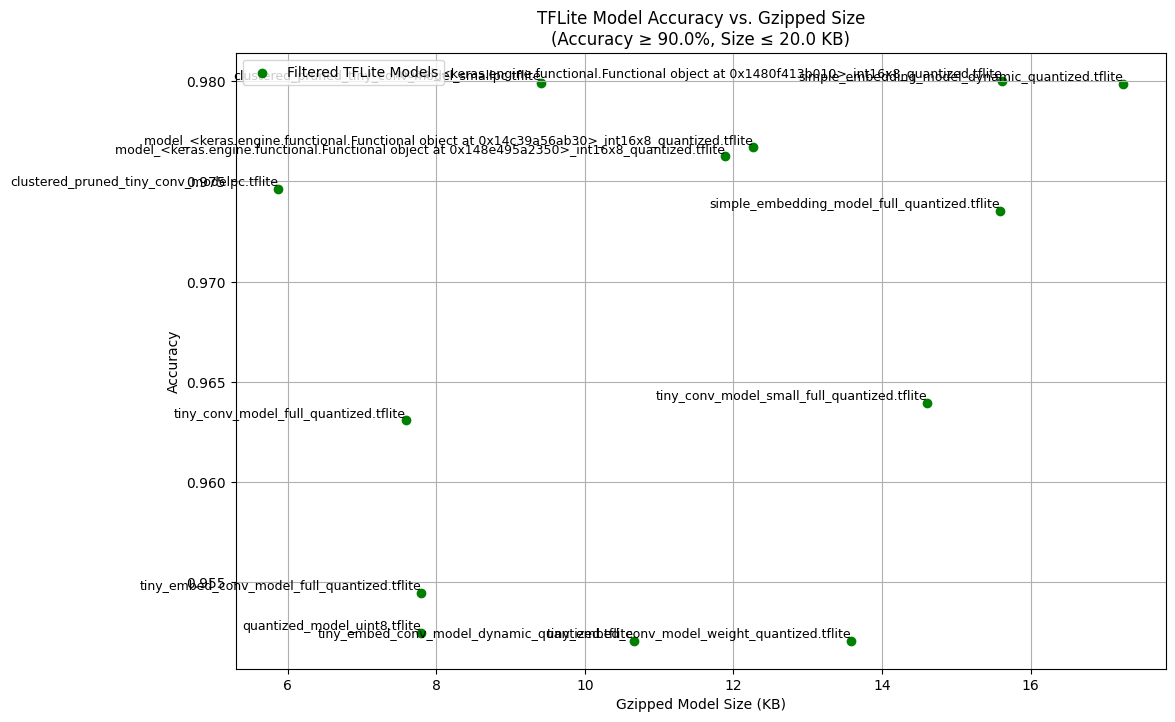

In [220]:
# Set your desired thresholds
desired_min_accuracy = 0.90  # 96% minimum accuracy
desired_max_size = 20.0       # 50 KB maximum gzipped size

# Evaluate and plot models based on the specified thresholds
evaluate_and_plot_tflite_models(
    directory=current_directory,
    test_dataset=test_spectrogram_ds,
    min_accuracy=desired_min_accuracy,
    max_size=desired_max_size
)

In [ ]:
#plot_filtered_model_size_vs_accuracy(model_sizes, accuracies, model_names, max_size=10, min_accuracy=0.90)

In [ ]:
def tflite_to_c_array(tflite_file, output_header):
    with open(tflite_file, 'rb') as f:
        data = f.read()

    array_name = 'model_data'
    with open(output_header, 'w') as f:
        f.write(f'const unsigned char {array_name}[] = {{\n  ')
        for i, byte in enumerate(data):
            f.write(f'0x{byte:02x}, ')
            if (i + 1) % 12 == 0:
                f.write('\n  ')
        f.write(f'\n}};\n')
        f.write(f'const unsigned int {array_name}_len = {len(data)};\n')


In [ ]:
# Usage
tflite_to_c_array('qat_sequential_23.tflite', 'qat_sequential_23.cc')

In [ ]:
!ls

In [ ]:
!xxd -i pruned_clustered_qat_simple_embedding_model.tflite > pcq_model.cc


In [ ]:
!xxd -i quantized_model_int8.tflite > pruned_clustered_int8.cc


In [ ]:
!xxd -i quantized_model_int8.tflite > pruned_clustered_int8.cc


In [ ]:
!xxd -i sequential_63_full_quantized.tflite > micro_model_smallest.cc


In [161]:
print(input_scale)
print(input_zero_point)

0.09361949563026428
20


In [162]:
print("Input shape expected by the model:", input_details['shape'])

Input shape expected by the model: [   1 1960]


In [163]:
correct_predictions = 0
for i in range(len(test_data)):
    interpreter.set_tensor(input_details["index"], test_data[i])
    interpreter.invoke()
    output = interpreter.get_tensor(output_details["index"])[0]
    top_prediction = output.argmax()
    correct_predictions += (top_prediction == y_test[i])

print('model accuracy is %f%% (Number of test samples=%d)' % (
    (correct_predictions * 100) / len(X_test), len(X_test)))

model accuracy is 47.923199% (Number of test samples=54218)
